In [24]:
import pandas as pd
from pathlib import Path

counts_R_tsv = "/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Normalization/S/all_R/combat_seq.tsv"
counts_E_tsv = "/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Normalization/S/E1/counts.tsv"

counts_R_df = pd.read_csv(counts_R_tsv, sep='\t')
counts_R_df = counts_R_df.rename(columns={'Unnamed: 0' : "name" })

counts_E_df = pd.read_csv(counts_E_tsv, sep='\t')
counts_E_df = counts_E_df.rename(columns={'Unnamed: 0' : "name" })

names_R = set(counts_R_df['name'])
names_E = set(counts_E_df['name'])

all_names = names_E.union(names_R)
all_names_df = pd.DataFrame({'name' : list(all_names)})
all_names_df = pd.merge(all_names_df, counts_E_df, on='name', how='left' )
all_names_df = pd.merge(all_names_df, counts_R_df, on='name', how='left' )


out_dir = Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Normalization/S/E1R_manual')
out_dir.mkdir(exist_ok=True)
all_names_df.to_csv(out_dir / 'joined_counts.csv', sep=',', index=False)

In [25]:
import pandas as pd

counts_csv = '/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Data/merge_bracken/S/merged_S_counts_filtered.csv'
counts_csv = '/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Data/merge_bracken/S/merged_S_counts_filtered.csv'
counts_csv = '/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Normalization/S/E1R_manual/joined_counts.csv'
taxa_tsv = '/home/jpereira/Results/kraken_snake/cow_db_table/cow_rumen_db_species.tsv'

taxa_df = pd.read_csv(taxa_tsv, sep='\t', )
counts_df = pd.read_csv(counts_csv, sep=',')

taxa_df.columns = taxa_df.columns[1::].append(pd.Index(['sp_name']))

taxa_df['species'] = taxa_df['species'] + " " + taxa_df['sp_name'].fillna('')
taxa_df['species'] = taxa_df['species'].str.strip() 
taxa_df['name'] = taxa_df['species']

merged_df = pd.merge(taxa_df, counts_df, on='name', how='inner')
merged_df


merge_tsv = '/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Data/merge_bracken/taxa_counts.tsv' 
merge_tsv = '/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Data/merge_bracken/taxa_counts.tsv' 
merge_tsv = '/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db_no_filter/Data/merge_bracken/norm_taxa_counts.tsv' 
merged_df.to_csv(merge_tsv, sep='\t', index=False)

#taxa_df[taxa_df['genus'].str.startswith("MG")]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity

def _plot_pcoa_variance_topn(pcoa_res,
                             n: int = 5,
                             fig_path: str = "pcoa_variance_topn.png",
                             show_plot: bool = True,
                             title: str | None = None):
    """
    Barplot of the PCoA variance explained: first n PCs individually,
    remaining PCs grouped into a single bar.
    """
    # proportions as percentages
    var_exp = np.asarray(pcoa_res.proportion_explained) * 100.0

    # guardrails
    if n < 1:
        n = 1
    n = min(n, len(var_exp))

    # split top-n and remainder
    top = var_exp[:n]
    rest = var_exp[n:]
    labels = [f"PC{i+1}" for i in range(n)]
    values = list(top)
    if rest.size > 0:
        labels.append(f"PC{n+1}+")
        values.append(rest.sum())

    # barplot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, edgecolor="black")
    plt.ylabel("Variance Explained (%)")
    plt.xlabel("Principal Coordinate")
    if title:
        plt.title(title)
    else:
        plt.title(f"PCoA variance explained (first {n} PCs + remainder)")

    # add data labels
    for rect, v in zip(bars, values):
        plt.text(rect.get_x() + rect.get_width()/2.0, v + 0.6, f"{v:.1f}%",
                 ha="center", va="bottom")

    plt.ylim((0,100))
    plt.tight_layout()
    plt.savefig(fig_path, dpi=300)
    if show_plot:
        plt.show()
    plt.close()

    # return a tidy table of what was plotted (useful in reports)
    out = pd.DataFrame({"component": labels, "variance_pct": values})
    return out

def make_pcoa(
    abundance_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    hue_col: str,
    fig_path: str,
    metric: str = "euclidean",
    intersect_dfs: bool = False,
    show_plot: bool = False,
    title: str = "",
    # NEW:
    varplot_n: int = 5,
    varplot_path: str = "pcoa_variance_topn.png",
    varplot_title: str = ""
):
    # 1) Optional: align samples
    if intersect_dfs:
        shared = abundance_df.index.intersection(metadata_df.index)
        abundance_df = abundance_df.loc[shared]
        metadata_df  = metadata_df.loc[shared]

    # 2) distance matrix
    METRICS_REQUIRE_NONNEG = {"braycurtis", "jaccard", "unweighted_unifrac", "weighted_unifrac"}
    metric = metric.lower()
    if metric in METRICS_REQUIRE_NONNEG:
        validate = True
    else:
        validate = False

    dm = beta_diversity(metric, abundance_df.values, ids=abundance_df.index.astype(str), validate=validate)

    # 3) PCoA
    pcoa_res = pcoa(DistanceMatrix(dm, ids=abundance_df.index.astype(str)))

    # 4) save coordinates
    coords = pcoa_res.samples
    coords.to_csv("pcoa_coordinates.tsv", sep="\t", header=True)

    # 5) merge with metadata (if you want the scatter)
    coords_meta = coords.join(metadata_df)

    # 6) scatter of PC1 vs PC2 (optional)
    if show_plot:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=coords_meta,
            x="PC1", y="PC2",
            hue=hue_col,
            palette="Set2",
            s=100, edgecolor="black"
        )
        var1 = pcoa_res.proportion_explained[0]*100
        var2 = pcoa_res.proportion_explained[1]*100
        plt.xlabel(f"PC1 ({var1:.1f}%)")
        plt.ylabel(f"PC2 ({var2:.1f}%)")
        plt.title(title if title else f"PCoA ({metric}) colored by {hue_col}")
        plt.grid(True)
        plt.legend(title=hue_col)
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
        plt.close()

    # 7) variance barplot: first n + remainder
    var_table = _plot_pcoa_variance_topn(
        pcoa_res,
        n=varplot_n,
        fig_path=varplot_path,
        show_plot=show_plot,
        title=varplot_title
    )

    # Return what’s useful to reuse downstream
    return {
        "PC1": pcoa_res.samples["PC1"],
        "PC2": pcoa_res.samples["PC2"],
        "variance_table": var_table,
        "pcoa_res": pcoa_res,
    }


In [2]:
def make_pcoa(
    abundance_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    hue_col: str,
    fig_path: str,
    metric: str = "euclidean",
    intersect_dfs: bool = False,
    show_plot: bool = False,
    title: str = "",
    # NEW (existing)
    varplot_n: int = 5,
    varplot_path: str = "pcoa_variance_topn.png",
    varplot_title: str = "",
    # NEW (centroids)
    add_centroids: bool = True,
    centroid_marker: str = "X",
    centroid_size: int = 250,
):
    # 1) Optional: align samples
    if intersect_dfs:
        shared = abundance_df.index.intersection(metadata_df.index)
        abundance_df = abundance_df.loc[shared]
        metadata_df  = metadata_df.loc[shared]

    # 2) distance matrix
    METRICS_REQUIRE_NONNEG = {
        "braycurtis",
        "jaccard",
        "unweighted_unifrac",
        "weighted_unifrac",
    }
    metric = metric.lower()
    validate = metric in METRICS_REQUIRE_NONNEG

    dm = beta_diversity(
        metric,
        abundance_df.values,
        ids=abundance_df.index.astype(str),
        validate=validate,
    )

    # 3) PCoA
    pcoa_res = pcoa(DistanceMatrix(dm, ids=abundance_df.index.astype(str)))

    # 4) save coordinates
    coords = pcoa_res.samples
    coords.to_csv("pcoa_coordinates.tsv", sep="\t", header=True)

    # 5) merge with metadata (if you want the scatter)
    coords_meta = coords.join(metadata_df)

    # Precompute variance explained for labels
    var1 = pcoa_res.proportion_explained[0] * 100
    var2 = pcoa_res.proportion_explained[1] * 100

    # 6) scatter of PC1 vs PC2 (optional)
    centroids = None
    if show_plot:
        plt.figure(figsize=(8, 6))
        ax = sns.scatterplot(
            data=coords_meta,
            x="PC1", y="PC2",
            hue=hue_col,
            palette="Set2",
            s=100,
            edgecolor="black",
        )

        # --- NEW: compute and plot centroids ---
        if add_centroids:
            centroids = (
                coords_meta
                .groupby(hue_col)[["PC1", "PC2"]]
                .mean()
                .reset_index()
            )

            # Plot centroids as larger markers
            sns.scatterplot(
                data=centroids,
                x="PC1", y="PC2",
                hue=hue_col,
                palette="Set2",
                s=centroid_size,
                marker=centroid_marker,
                edgecolor="black",
                legend=False,  # keep legend from first scatter
                ax=ax,
            )

            # Optional: label centroids with group name
            for _, row in centroids.iterrows():
                ax.text(
                    row["PC1"],
                    row["PC2"],
                    str(row[hue_col]),
                    ha="center",
                    va="center",
                    fontsize=9,
                    weight="bold",
                )

        ax.set_xlabel(f"PC1 ({var1:.1f}%)")
        ax.set_ylabel(f"PC2 ({var2:.1f}%)")
        ax.set_title(title if title else f"PCoA ({metric}) colored by {hue_col}")
        ax.grid(True)
        ax.legend(title=hue_col)
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
        plt.close()

    # 7) variance barplot: first n + remainder
    var_table = _plot_pcoa_variance_topn(
        pcoa_res,
        n=varplot_n,
        fig_path=varplot_path,
        show_plot=show_plot,
        title=varplot_title,
    )

    # Return what’s useful to reuse downstream
    return {
        "PC1": pcoa_res.samples["PC1"],
        "PC2": pcoa_res.samples["PC2"],
        "variance_table": var_table,
        "pcoa_res": pcoa_res,
        "centroids": centroids,  # NEW: None if add_centroids=False
    }


In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# ─── Settings ────────────────────────────────────────────────────────────────
MG2_GTDB_S_settings = {
    'kraken_report_dir': Path('/home/jpereira/Results/kraken_snake/MG2_20M/Data/kraken2/'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/G/metadata/metadata.NS_R.tsv'),
    'title': 'MG2_GTDB_S (CS 0.3)',
    'output_dir': Path('/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/'),
    'id_col': 'LABID',        # column in metadata with sample IDs matching Kraken report folder names
    'group_col': 'Group',     # column in metadata used to group the boxplot
}

MG2_GTDB_S_settings = {
    'kraken_report_dir': Path('/home/jpereira/Results/kraken_snake/MG2_20M/Data/kraken2/'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/metadata/S/NS_R/metadata.tsv'),
    'title': 'MG2_GTDB_S (CS 0.3)',
    'output_dir': Path('/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/'),
    'id_col': 'LABID',        # column in metadata with sample IDs matching Kraken report folder names
    'group_col': 'Group',     # column in metadata used to group the boxplot
}

MG1_GTDB_S_settings = {
    'kraken_report_dir': Path('/home/jpereira/Results/kraken_snake/MG1_20M/Data/kraken2/'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/metadata/S/all_R/metadata.tsv'),
    'title': 'MG2_GTDB_S (CS 0.3)',
    'output_dir': Path('/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/'),
    'id_col': 'LABID',        # column in metadata with sample IDs matching Kraken report folder names
    'group_col': 'Group',     # column in metadata used to group the boxplot
}


load_settings = {
    'MG2_GTDB_S': MG2_GTDB_S_settings,
    'MG1_GTDB_S': MG1_GTDB_S_settings
}

work_name = 'MG1_GTDB_S'
cfg = load_settings[work_name]

kraken_report_dir = cfg['kraken_report_dir']
metadata_tsv = cfg['metadata_tsv']
output_dir = cfg['output_dir']
title = cfg['title']
id_col = cfg['id_col']
group_col = cfg['group_col']

output_dir.mkdir(parents=True, exist_ok=True)

# ─── Read metadata once ──────────────────────────────────────────────────────
metadata_df = pd.read_csv(metadata_tsv, sep='\t')
if id_col not in metadata_df.columns:
    raise ValueError(f"'{id_col}' not found in metadata columns: {list(metadata_df.columns)}")
if group_col not in metadata_df.columns:
    raise ValueError(f"'{group_col}' not found in metadata columns: {list(metadata_df.columns)}")

# Keep only needed columns and ensure sample IDs are strings
metadata_df[id_col] = metadata_df[id_col].astype(str)
meta_small = metadata_df[[id_col, group_col]].dropna()

# ─── Collect classified % per sample ─────────────────────────────────────────
rows = []
for sample_dir in kraken_report_dir.iterdir():
    if not sample_dir.is_dir():
        continue

    sample_name = sample_dir.name  # expects folder name == sample ID in metadata[id_col]
    kraken_report_file = sample_dir / f"{sample_name}.kraken2.report"

    if not kraken_report_file.exists():
        print(f"[WARN] Kraken report file not found for {sample_name}")
        continue

    df = pd.read_csv(
        kraken_report_file,
        sep='\t',
        header=None,
        names=['percentage', 'reads_clade', 'reads_taxon', 'rank', 'ncbi_taxid', 'name'],
        index_col=False
    )

    # Assume Krake2 report has a unique 'unclassified' row
    unclassified = df.loc[df['name'] == 'unclassified', 'percentage']
    if unclassified.empty:
        print(f"[WARN] No 'unclassified' row in {kraken_report_file.name}; skipping {sample_name}")
        continue

    classified_pct = 100.0 - float(unclassified.values[0])
    rows.append({'sample': str(sample_name), 'classified_percentage': classified_pct})

abundances_df = pd.DataFrame(rows)

# ─── Merge abundances with metadata ──────────────────────────────────────────
merged = abundances_df.merge(
    meta_small,
    left_on='sample',
    right_on=id_col,
    how='left',
    validate='m:1'
)

missing_group = merged[group_col].isna().sum()
if missing_group > 0:
    missing_samples = merged.loc[merged[group_col].isna(), 'sample'].tolist()
    print(f"[WARN] {missing_group} sample(s) lack '{group_col}' in metadata. Examples: {missing_samples[:5]}")

# Drop rows without grouping info (or keep them as a separate category if you prefer)
plot_df = merged.dropna(subset=[group_col])

# ─── Plot: boxplot grouped by metadata category ──────────────────────────────
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=plot_df,
    x=group_col,
    y='classified_percentage'
)
sns.stripplot(
    data=plot_df,
    x=group_col,
    y='classified_percentage',
    dodge=True,
    alpha=0.55
)

ax.set_xlabel(group_col)
ax.set_ylabel('Classified Percentage')
ax.set_ylim(0, 100)
ax.set_title(f'{title} — Classified Reads Percentage by {group_col}')
plt.tight_layout()

# Save and/or show
out_png = output_dir / f"classified_percentage_by_{group_col}_{work_name}.png"
plt.savefig(out_png, dpi=300)
plt.show()
print(f"[OK] Saved: {out_png}")


FileNotFoundError: [Errno 2] No such file or directory: '/home/jpereira/Results/kraken_snake/MG1_20M/Data/kraken2'

Saved table: /home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/taxa_counts_per_sample_MG1_MG2_cow_db_S.csv


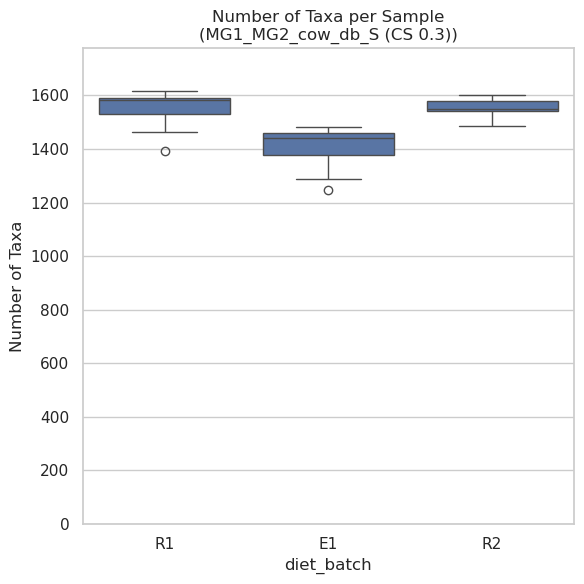

Saved plot: /home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/num_taxa_per_sample_boxplot_MG1_MG2_cow_db_S.png


In [ ]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# ─── Settings ────────────────────────────────────────────────────────────────

MG2_GTDB_S_settings = {
    'raw_counts_tsv': Path('/home/jpereira/Results/kraken_snake/MG2_20M/Data/merge_bracken/S/bracken_merged_S_new_est_reads.csv'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/S/metadata/metadata.NS_R.tsv'),
    'title': 'MG2_GTDB_S (CS 0.3)',
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/"),
    
    # NEW options for relative abundance filtering
    'apply_rel_abundance_filter': True,   # Set to False to disable filtering
    'rel_abundance_threshold': 0.00001,    # 0.001% = 0.0001 in relative abundance
}

MG1_PR_E_GTDB_S_settings = {
    'counts_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Normalization/S/PR_E/counts.tsv'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/metadata/S/PR_E/metadata.tsv'),
    'title': 'MG1_PR_E_GTDB_S (CS 0.3)',
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/PR_E/"),
    'params_counts_sep': '\t',
    # NEW options for relative abundance filtering
    'apply_rel_abundance_filter': False,   # Set to False to disable filtering
    'rel_abundance_threshold': 0.00001,    # 0.001% = 0.0001 in relative abundance
}

MG1_PR_R_GTDB_S_settings = {
    'counts_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Normalization/S/PR_R/counts.tsv'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/metadata/S/PR_R/metadata.tsv'),
    'title': 'MG1_PR_R_GTDB_S (CS 0.3)',
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/PR_R/"),
    'params_counts_sep': '\t',
    # NEW options for relative abundance filtering
    'apply_rel_abundance_filter': False,   # Set to False to disable filtering
    'rel_abundance_threshold': 0.00001,    # 0.001% = 0.0001 in relative abundance
}

MG1_NS_R_GTDB_S_settings = {
    'counts_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Normalization/S/NS_R/counts.tsv'),
    'metadata_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/metadata/S/NS_R/metadata.tsv'),
    'title': 'MG1_NS_R_GTDB_S (CS 0.3)',
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/NS_R/"),
    'params_counts_sep': '\t',
    # NEW options for relative abundance filtering
    'apply_rel_abundance_filter': False,   # Set to False to disable filtering
    'rel_abundance_threshold': 0.00001,    # 0.001% = 0.0001 in relative abundance
}


MG1_MG2_cowdb_settings = {
    'counts_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Data/merge_bracken/S/merged_S_counts_filtered.csv'),
    'metadata_tsv': Path('/home/jpereira/kraken_snake/metadata/metadata.MG1_MG2.csv'),
    'title': 'MG1_MG2_cow_db_S (CS 0.3)',
    'group': 'Group',
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/"),
    'params_counts_sep': '\t',
    # NEW options for relative abundance filtering
    'apply_rel_abundance_filter': False,   # Set to False to disable filtering
    'rel_abundance_threshold': 0.00001,    # 0.001% = 0.0001 in relative abundance
}

load_settings = {
    'MG2_GTDB_S': MG2_GTDB_S_settings,
    'MG1_PR_E_GTDB_S': MG1_PR_E_GTDB_S_settings,
    'MG1_PR_R_GTDB_S': MG1_PR_R_GTDB_S_settings,
    'MG1_NS_R_GTDB_S': MG1_NS_R_GTDB_S_settings,
    'MG1_MG2_cow_db_S': MG1_MG2_cowdb_settings,
}
work_name = 'MG1_MG2_cow_db_S'

MG1_MG2_cowdb_settings = {
    'counts_tsv': Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Data/merge_bracken/S/merged_S_counts_filtered.csv'),
    'metadata_tsv': Path('/home/jpereira/old.kraken_snake/metadata/metadata.M1_M2.tsv'),
    'title': 'MG1_MG2_cow_db_S (CS 0.3)',
    'group': 'diet_batch',                     # column in metadata with group labels
    'metadata_sample_col': 'mg_work_id', 
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/"),
    'params_counts_sep': ',',            # adjust if your counts file is comma-separated
    # Relative abundance filtering
    'apply_rel_abundance_filter': False,
    'rel_abundance_threshold': 1e-5,      # 0.001% = 1e-5
    'rel_abundance_filter_mode': 'per_sample_any',  # 'per_sample_any' or 'mean'
    # If your metadata file is actually comma-separated, set this to ','
    'metadata_sep': '\t',                  # safer default for .csv
}

load_settings = {
    # ... your other presets ...
    'MG1_MG2_cow_db_S': MG1_MG2_cowdb_settings,
}
work_name = 'MG1_MG2_cow_db_S'

cfg = load_settings[work_name]
counts_tsv = cfg['counts_tsv']
metadata_tsv = cfg['metadata_tsv']
params_counts_sep = cfg.get('params_counts_sep', ',')
group_col = cfg.get('group', 'Group')
meta_id_col = cfg.get('metadata_sample_col', 'sample')
title = cfg['title']
output_dir = cfg['output_dir']
output_dir.mkdir(parents=True, exist_ok=True)

# ─── Load data ───────────────────────────────────────────────────────────────
abundances_df = pd.read_csv(counts_tsv, sep=params_counts_sep, index_col=0)
abundances_df = abundances_df.astype(float)

# Try to read metadata with configured separator; fall back to autodetect if needed
try:
    metadata_df = pd.read_csv(metadata_tsv, sep=cfg.get('metadata_sep', ','))
except Exception:
    metadata_df = pd.read_csv(metadata_tsv, sep=None, engine='python')

# ─── Optional relative abundance filter ──────────────────────────────────────
if cfg['apply_rel_abundance_filter']:
    print(f"Applying relative abundance filter ({cfg['rel_abundance_filter_mode']}): "
          f"threshold = {cfg['rel_abundance_threshold']*100:.4f}%")

    # Columns are samples; rows are taxa
    rel_abundances = abundances_df.div(abundances_df.sum(axis=0), axis=1)

    mode = cfg.get('rel_abundance_filter_mode', 'per_sample_any')
    if mode == 'mean':
        # keep taxa whose MEAN relative abundance across samples >= threshold
        mean_rel = rel_abundances.mean(axis=1)
        taxa_to_keep = mean_rel[mean_rel >= cfg['rel_abundance_threshold']].index
    elif mode == 'per_sample_any':
        # keep taxa that are >= threshold in at least one sample
        mask = rel_abundances.ge(cfg['rel_abundance_threshold'])
        taxa_to_keep = rel_abundances[mask].dropna(how='all').index
    else:
        raise ValueError("rel_abundance_filter_mode must be 'per_sample_any' or 'mean'")

    before, after = abundances_df.shape[0], len(taxa_to_keep)
    abundances_df = abundances_df.loc[taxa_to_keep]
    print(f"Filtered taxa: kept {after}/{before} ({after/before*100:.2f}%)")

# ─── Compute number of taxa per sample ───────────────────────────────────────
taxa_counts = (abundances_df > 0).sum(axis=0)               # Series indexed by sample
taxa_counts_df = taxa_counts.rename('num_taxa').reset_index()
taxa_counts_df = taxa_counts_df.rename(columns={'index': 'sample'})

# ─── Merge group labels from metadata ────────────────────────────────────────
if meta_id_col not in metadata_df.columns:
    raise KeyError(f"Column '{meta_id_col}' not found in metadata. "
                   f"Available columns: {list(metadata_df.columns)}")

if group_col not in metadata_df.columns:
    raise KeyError(f"Group column '{group_col}' not found in metadata. "
                   f"Available columns: {list(metadata_df.columns)}")

# Keep only the needed columns from metadata and ensure types match
meta_keep = metadata_df[[meta_id_col, group_col]].copy()
meta_keep[meta_id_col] = meta_keep[meta_id_col].astype(str)
taxa_counts_df['sample'] = taxa_counts_df['sample'].astype(str)

taxa_counts_df = taxa_counts_df.merge(
    meta_keep, left_on='sample', right_on=meta_id_col, how='left'
).drop(columns=[meta_id_col])

missing_groups = taxa_counts_df[group_col].isna().sum()
if missing_groups > 0:
    print(f"Warning: {missing_groups} samples in counts were not matched to metadata.")

# ─── Save counts table ───────────────────────────────────────────────────────
counts_table_path = output_dir / (f'taxa_counts_per_sample_{work_name}.csv'
                                  if not cfg['apply_rel_abundance_filter']
                                  else 'taxa_counts_per_sample.filtered.csv')
taxa_counts_df.to_csv(counts_table_path, index=False)
print(f"Saved table: {counts_table_path}")

# ─── Plot ───────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))
sns.boxplot(x=group_col, y='num_taxa', data=taxa_counts_df, orient='v')
plt.ylabel('Number of Taxa')
plt.xlabel(group_col)
plt.title(f'Number of Taxa per Sample\n({title})')
plt.ylim(bottom=0, top=taxa_counts.max() * 1.1)
plt.tight_layout()

output_path = (output_dir / 'num_taxa_per_sample_boxplot.filtered.png'
               if cfg['apply_rel_abundance_filter']
               else output_dir / f'num_taxa_per_sample_boxplot_{work_name}.png')
plt.savefig(output_path, dpi=300)
plt.show()
print(f"Saved plot: {output_path}")


/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)
/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)
/home/jpereira/kraken_snake/scripts/utils/plots_utils.py:287: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var1 = pcoa_res.proportion_explained[0] * 100
/home/jpereira/kraken_snake/scripts/utils/plots_utils.py:288: FutureWarning: Series.__getitem__ tr

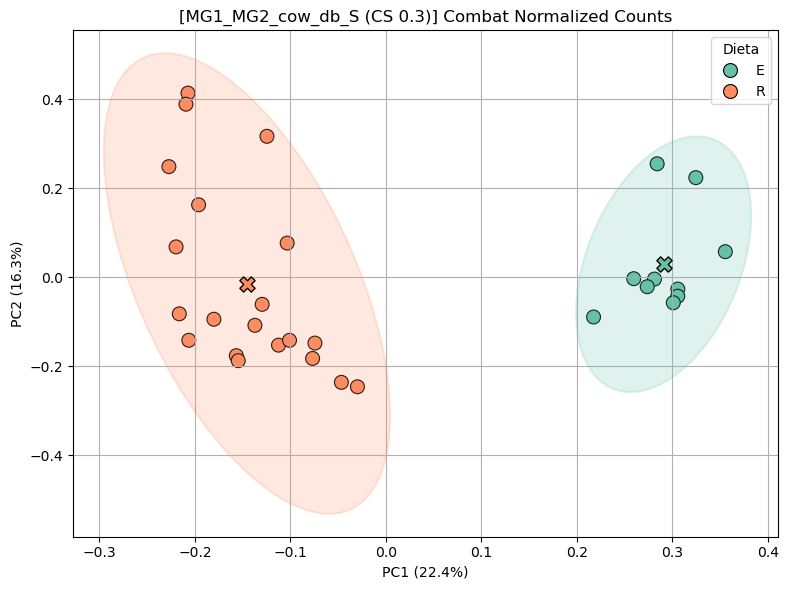

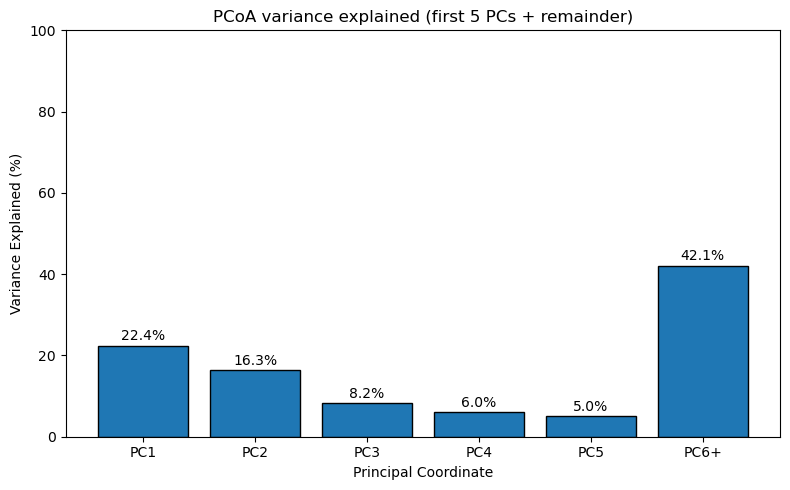

/home/jpereira/kraken_snake/scripts/utils/plots_utils.py:287: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var1 = pcoa_res.proportion_explained[0] * 100
/home/jpereira/kraken_snake/scripts/utils/plots_utils.py:288: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var2 = pcoa_res.proportion_explained[1] * 100


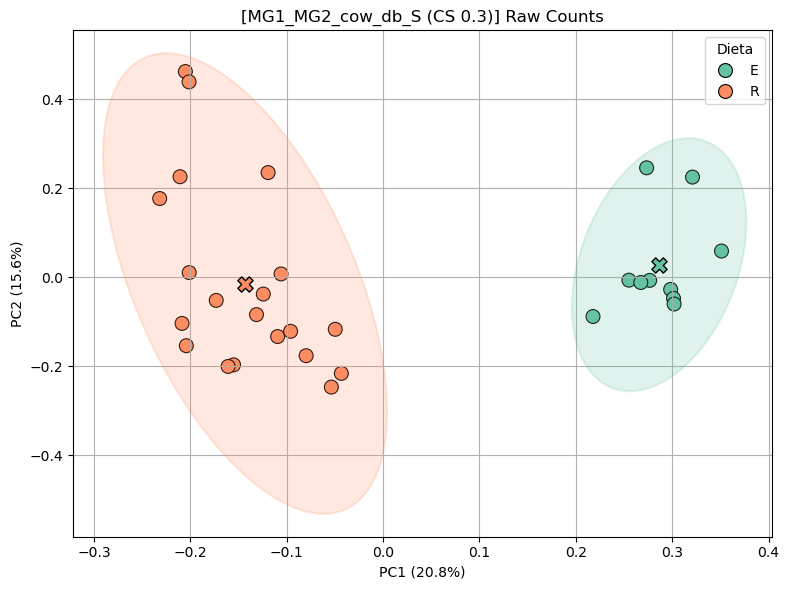

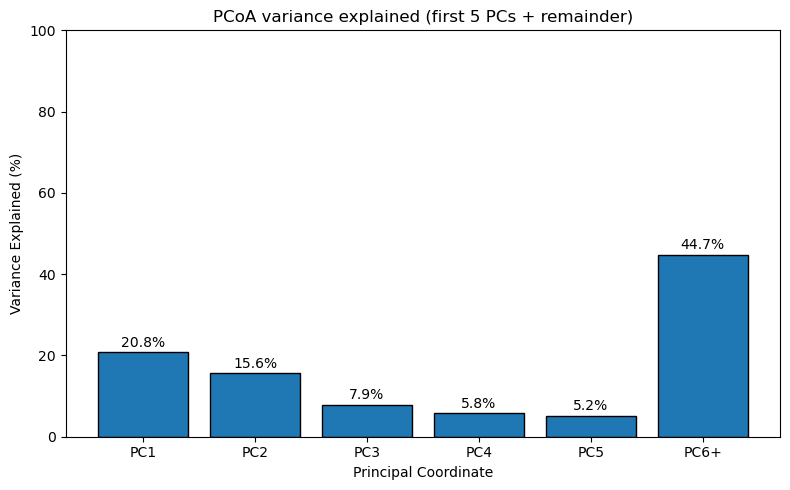

Completed work: MG1_MG2_cow_db_S_all_diet


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.stats.ordination import pcoa
from skbio.stats.distance import DistanceMatrix
from skbio.diversity import beta_diversity
from pathlib import Path
from utils.plots_utils import make_pca, make_pcoa, make_pcoa2, make_pcoa3
from utils.files_utils import load_metadata, load_counts

#MG1_MG2_GTDB_S_R_settings = {
#    'raw_counts_tsv' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/counts/S/all_R/counts.tsv'),
#    'combat_counts_tsv' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Normalization/S/all_R/combat_seq.tsv'),
#    'input_metadata_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/S/metadata/'),
#    'metadata_tsv' : Path("/home/jpereira/old.kraken_snake/metadata/metadata.MG1_MG2.all_R.27_08_25.tsv"),
#    'comparision_name' : 'NS_R_vs_PR_R',
#    'title' : 'MG1_MG2_GTDB_S (CS 0.3)',
#    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Normalization/")
#    }

# MG1_MG2_cow_db_S_all_RFI_settings = {
#     'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv'),
#                         Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/E1//counts.tsv')],
#     'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
#                            Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
#     'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv'),
#                       Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
#     'metadata_id_col' : 'mg_work_id',
#     'hue_col' : 'Pheno_RFI',
#     'comparision_name' : 'all_groups_RFI',
#     'title' : 'MG1_MG2_cow_db_S Pheno RFI (CS 0.3)',
#     'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")

#     }

# MG1_MG2_cow_db_S_E_RFI_settings = {
#     'raw_counts_tsv' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/PR_E/counts.tsv'),
#     'combat_counts_tsv' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/PR_E/counts.tsv'),
#     'metadata_tsv' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv"),
#     'metadata_id_col' : 'mg_work_id',
#     'hue_col' : 'Pheno_RFI',
#     'comparision_name' : 'E_RFI',
#     'title' : 'E_cow_db_S (CS 0.3)',
#     'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")
#     }

# MG1_MG2_cow_db_S_R_RFI_settings = {
#     'raw_counts_tsv' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv'),
#     'combat_counts_tsv' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
#     'metadata_tsv' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv"),
#     'metadata_id_col' : 'mg_work_id',
#     'hue_col' : 'Pheno_RFI',
#     'comparision_name' : 'R_RFI',
#     'title' : 'all_R_cow_db_S Pheno_RFI (CS 0.3)',
#     'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")
#     }

MG1_MG2_cow_db_S_all_diet_batch_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv'),
                        Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/E1//counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
                           Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'diet_batch',
    'comparision_name' : 'all_groups_diet_batch',
    'title' : 'MG1_MG2_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")
    }

MG1_MG2_cow_db_S_all_diet_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv'),
                        Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/E1//counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
                           Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Dieta',
    'comparision_name' : 'all_groups_diet',
    'title' : 'MG1_MG2_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")
    }

MG1_MG2_cow_db_S_R_RFI_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Pheno_RFI',
    'comparision_name' : 'MG1_MG2_R_RFI',
    'title' : 'MG1_MG2_R_cow_db_S_Pheno_RFI (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")

    }

MG1_MG2_cow_db_S_R_DMP_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Pheno_DMP',
    'comparision_name' : 'MG1_MG2_R_DMP',
    'title' : 'MG1_MG2_R_cow_db_S_Pheno_DMP (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")
    }

MG1_MG2_cow_db_S_R_MeY_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/all_R/counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Pheno_MeY',
    'comparision_name' : 'MG1_MG2_R_MeY',
    'title' : 'MG1_MG2_R_cow_db_S_Pheno_MeY (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")

    }

MG1_MG2_cow_db_S_E_RFI_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/E1/counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Pheno_RFI',
    'comparision_name' : 'MG1_MG2_E_RFI',
    'title' : 'MG1_MG2_E_cow_db_S_Pheno_RFI (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")

    }

MG1_MG2_cow_db_S_E_DMP_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/E1/counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Pheno_DMP',
    'comparision_name' : 'MG1_MG2_E_DMP',
    'title' : 'MG1_MG2_E_cow_db_S_Pheno_DMP (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")

    }



MG1_MG2_cow_db_S_E_MeY_settings = {
    'raw_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/E1/counts.tsv')],
    'combat_counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'hue_col' : 'Pheno_MeY',
    'comparision_name' : 'MG1_MG2_E_MeY',
    'title' : 'MG1_MG2_E_cow_db_S_Pheno_MeY (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/")

    }






load_settings = {
    #'MG1_MG2_S_all_R_GTDB' : MG1_MG2_GTDB_S_R_settings,
    #'MG1_MG2_S_all_PR_E_GTDB' : MG1_MG2_GTDB_S_all_settings,
    'MG1_MG2_cow_db_S_all_diet': MG1_MG2_cow_db_S_all_diet_settings,
    'MG1_MG2_cow_db_S_all_diet_batch' : MG1_MG2_cow_db_S_all_diet_batch_settings,
    #'MG1_MG2_S_R_cow_db' : MG1_MG2_cow_db_S_R_settings,
    #'MG1_MG2_cow_db_S_all_RFI' : MG1_MG2_cow_db_S_all_RFI_settings,
    'MG1_MG2_cow_db_S_E_RFI' : MG1_MG2_cow_db_S_E_RFI_settings,
    'MG1_MG2_cow_db_S_E_MeY' : MG1_MG2_cow_db_S_E_MeY_settings,
    'MG1_MG2_cow_db_S_E_DMP' : MG1_MG2_cow_db_S_E_DMP_settings,
    'MG1_MG2_cow_db_S_R_RFI' : MG1_MG2_cow_db_S_R_RFI_settings,
    'MG1_MG2_cow_db_S_R_MeY' : MG1_MG2_cow_db_S_R_MeY_settings,
    'MG1_MG2_cow_db_S_R_DMP' : MG1_MG2_cow_db_S_R_DMP_settings,

}

for key, values in load_settings.items():

    try:
        work_name=key

        raw_counts_tsv = load_settings[work_name]['raw_counts_tsv']
        combat_counts_tsv = load_settings[work_name]['combat_counts_tsv']
        comparision_name = load_settings[work_name]['comparision_name']
        meta_id_col = load_settings[work_name].get('metadata_id_col', 'sample')
        hue_col = load_settings[work_name].get('hue_col', 'Group')
        title = load_settings[work_name]['title']
        metadata_tsv = load_settings[work_name]['metadata_tsv']
        output_dir = load_settings[work_name]['output_dir']

        output_pcoa_dir = output_dir / "PCOA"
        output_pcoa_dir.mkdir(exist_ok=True)

        # ─── Load data ───────────────────────────────────────────────────────────────
        raw_counts_df = load_counts(raw_counts_tsv, sep='\t', index_col=0, transpose=False).T
        combat_counts_df = load_counts(combat_counts_tsv, sep='\t', index_col=0, transpose=True).T
        metadata_df = load_metadata(metadata_tsv, sep='\t', id_col=meta_id_col)

        pcoa_res_combat = make_pcoa3(abundance_df=combat_counts_df, metadata_df=metadata_df, fig_path=output_pcoa_dir / f"combat.{comparision_name}.svg", hue_col=hue_col, metric='braycurtis', show_plot=True, title=f'[{title}] Combat Normalized Counts', add_centroids=True, run_stats=True)
        pcoa_res_raw = make_pcoa3(abundance_df=raw_counts_df, metadata_df=metadata_df, fig_path=output_pcoa_dir / f"raw.{comparision_name}.svg", metric="braycurtis", hue_col=hue_col, show_plot=True, title=f'[{title}] Raw Counts', add_centroids=True, run_stats=True )

        var_table_combat = pcoa_res_combat['variance_table']
        permanova_combat = pcoa_res_combat['permanova']
        permadisp_combat = pcoa_res_combat['permdisp']

        var_table_raw = pcoa_res_raw['variance_table']
        permanova_raw = pcoa_res_raw['permanova']
        permadisp_raw = pcoa_res_raw['permdisp']

        var_table_combat.to_csv(output_pcoa_dir / f"combat.variance.{comparision_name}.tsv", sep='\t')
        permadisp_combat.to_csv(output_pcoa_dir / f"combat.permadisp.{comparision_name}.tsv", sep='\t')
        permanova_combat.to_csv(output_pcoa_dir / f"combat.permanova.{comparision_name}.tsv", sep='\t')

        var_table_raw.to_csv(output_pcoa_dir / f"raw.variance{comparision_name}.tsv", sep='\t')
        permadisp_raw.to_csv(output_pcoa_dir / f"raw.permadisp.{comparision_name}.tsv", sep='\t')
        permanova_raw.to_csv(output_pcoa_dir / f"raw.permanova.{comparision_name}.tsv", sep='\t')
    except Exception as e:
        print(f"ERROR ({work_name}: {e})")
    else:
        print(f"Completed work: {work_name}")
    break



In [18]:
raw_counts_df.to_csv('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/counts/S/post_merged/old_bad_merged_counts.tsv', sep='\t')



In [10]:
from pathlib import Path
from typing import Iterable, Union, List
import pandas as pd
import glob

PathLike = Union[str, Path, Iterable[Union[str, Path]]]

def _coerce_to_paths(src: PathLike) -> List[Path]:
    """Accept str/Path, list/tuple of paths, or globs; return a flat list of Path objects."""
    if isinstance(src, (str, Path)):
        src = [src]
    elif not isinstance(src, Iterable):
        raise TypeError("Expected a path, glob, or an iterable of them.")

    paths: List[Path] = []
    for item in src:
        p = str(item)
        # expand globs like "*.tsv"
        matches = glob.glob(p)
        if matches:
            paths.extend(Path(m) for m in matches)
        else:
            paths.append(Path(p))
    if not paths:
        raise FileNotFoundError("No files found for the provided input(s).")
    return paths

def load_counts(paths: PathLike, sep: str = "\t", index_col: int = 0, transpose: bool = False) -> pd.DataFrame:
    """
    Load one or many count matrices (features in rows), transpose each (samples as rows → columns),
    outer-join across files on the index, and fill missing with 0.
    """
    files = _coerce_to_paths(paths)
    if transpose:
        frames = [pd.read_csv(f, sep=sep, index_col=index_col) for f in files]    
    else:
        frames = [pd.read_csv(f, sep=sep, index_col=index_col).T for f in files]
        
    df = pd.concat(frames, axis=1, join="outer")
    # Ensure numeric where possible; then fill NAs with 0
    df = df.apply(pd.to_numeric, errors="ignore").fillna(0)
    return df

In [8]:
combat_counts_df.columns

Index(['51-20 sp902761715', 'AC2028 sp902761225', 'AC2028 sp902767075',
       'AC2028 sp902790935', 'AC2028 sp902794095', 'Absicoccus porci',
       'Acetatifactor sp900320485', 'Acetatifactor sp902796105',
       'Acetitomaculum sp902797785', 'Agathobacter faecis',
       ...
       'UMGS1696 sp902778205', 'UMGS1696 sp902782445', 'UMGS1696 sp902783705',
       'UMGS1696 sp902783755', 'UMGS1820 sp902777435', 'UMGS1865 sp902795355',
       'UMGS995 sp902784095', 'Weimerbacter sp900316165',
       'Weimerbacter sp902803645', 'Zag111 sp902766105'],
      dtype='object', length=3404)

In [6]:
for key in pcoa_res_raw.keys():
    print(key)

pcoa_res_raw['permdisp']

PC1
PC2
variance_table
pcoa_res
centroids
permanova
permdisp


method name               PERMDISP
test statistic name        F-value
sample size                     20
number of groups                 2
test statistic            0.825801
p-value                      0.381
number of permutations         999
Name: PERMDISP results, dtype: object

## Percent of reads classified by kraken

In [48]:
pd.read_csv("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv", sep='\t')

,mg_work_id,LABID,Dieta,DMI,ADG,BW,mBW,BFAT,RFI,Pheno_RFI,...,Vis,Days,MeI_BW,MeI_ADG,MeY_DMI,Pheno_MeY,Pheno_DMP,batch,mt_work_id,diet_batch
0,PR27NT012MG,PR27NT012,E,10.80,1.48,494.5,103.4,13.3,-0.846,High_Efficiency,...,86,46,0.50,168.69,23.06,High_MeY,High_DMP,A,PR27NT012MT,E1
1,PR27NT015MG,PR27NT015,E,13.42,1.60,552.8,113.4,15.0,0.684,Low_Efficiency,...,109,54,0.43,148.50,17.68,Low_MeY,Low_DMP,A,PR27NT015MT,E1
2,PR27NT020MG,PR27NT020,E,10.80,1.36,505.5,105.9,11.7,-0.720,High_Efficiency,...,45,32,0.57,213.10,26.77,High_MeY,High_DMP,A,PR27NT020MT,E1
3,PR27NT021MG,PR27NT021,E,14.01,1.79,524.8,108.4,11.4,1.440,Low_Efficiency,...,120,55,0.47,137.64,17.55,Low_MeY,Low_DMP,A,PR27NT021MT,E1
4,PR27NT045MG,PR27NT045,E,14.16,1.73,538.8,110.4,14.9,1.382,Low_Efficiency,...,59,39,0.46,143.36,17.55,Low_MeY,High_DMP,A,PR27NT045MT,E1
5,PR27NT046MG,PR27NT046,E,11.24,1.57,537.8,110.2,12.2,-1.072,High_Efficiency,...,94,48,0.46,156.63,21.90,High_MeY,Low_DMP,A,PR27NT046MT,E1
6,PR27NT048MG,PR27NT048,E,13.96,1.94,532.6,110.9,14.4,0.756,Low_Efficiency,...,157,59,0.49,134.81,18.71,Low_MeY,High_DMP,A,PR27NT048MT,E1
7,PR27NT054MG,PR27NT054,E,13.95,1.60,545.8,112.5,14.0,1.328,Low_Efficiency,...,104,44,0.45,153.07,17.53,Low_MeY,Low_DMP,A,PR27NT054MT,E1
8,PR27NT067MG,PR27NT067,E,9.36,1.54,477.6,101.0,13.2,-2.240,High_Efficiency,...,114,51,0.44,135.62,22.38,High_MeY,Low_DMP,A,PR27NT067MT,E1
9,PR27NT070MG,PR27NT070,E,11.35,1.44,537.3,110.4,12.2,-0.713,High_Efficiency,...,123,53,0.48,180.24,22.87,High_MeY,High_DMP,A,PR27NT070MT,E1


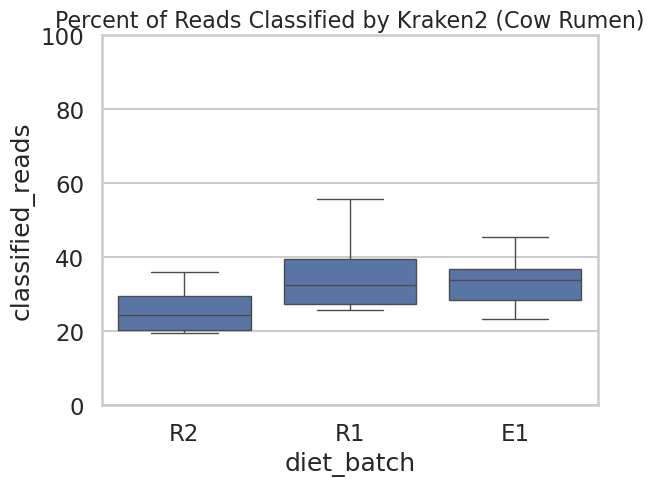

In [63]:
import subprocess
from pathlib import Path
import pandas as pd
from utils.files_utils import load_metadata

input_kraken_dirs = [
    Path('/home/jpereira/Results/kraken_snake/MG1_cow_db/Data/kraken2/'),
    Path('/home/jpereira/Results/kraken_snake/MG2_cow_db/Data/kraken2/')
]
input_metadata_tsv = [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R//metadata.tsv')]
params_id_col = 'mg_work_id'
params_plot_group = 'diet_batch'
params_title = 'Percent of Reads Classified by Kraken2 (Cow Rumen)'
output_dir = Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/kraken2/")

output_dir.mkdir(exist_ok=True, parents=True)

metadata_df = load_metadata(paths=input_metadata_tsv, id_col=params_id_col, sep='\t')


samples, unclassified_percent = [], []

for base in input_kraken_dirs:
    for sample_dir in base.iterdir():
        if not sample_dir.is_dir():
            continue

        report = sample_dir / f"{sample_dir.name}.kraken2.report"
        if not report.exists():
            print(f"Missing report for {sample_dir.name}")
            continue

        cmd = ["awk", '($4 == "U"){print $1}', str(report)]
        res = subprocess.run(cmd, capture_output=True, text=True, check=True)
        value = res.stdout.strip()
        if value == "":
            print(f"No 'U' line found in {report}")
            continue

        samples.append(sample_dir.name)
        unclassified_percent.append(float(value))

df = pd.DataFrame({params_id_col: samples, "unclassified_percent": unclassified_percent}) \
       .sort_values(params_id_col).reset_index(drop=True)
df['classified_reads'] = 100 - df['unclassified_percent']  



merge_df = pd.merge(df, metadata_df, on=params_id_col, how='inner' )

sns.boxplot(data=merge_df, x=params_plot_group, y='classified_reads')
plt.ylim((0,100))

plt.title(params_title, fontsize=16)
plt.savefig(output_dir / f"kraken2_percent_classified_reads.png")
plt.show()

In [8]:
# mg1_cl_kraken_tsv = '/home/jpereira/Results/kraken_snake/MG1_MG2/Data/kraken2/MG1_classification.tsv'
# mg2_cl_kraken_tsv = '/home/jpereira/Results/kraken_snake/MG1_MG2/Data/kraken2/MG2_classification.tsv'

# mg1_cl_kraken_df = pd.read_csv(mg1_cl_kraken_tsv, sep='\t')
# mg2_cl_kraken_df = pd.read_csv(mg2_cl_kraken_tsv, sep='\t')

# mg1_cl_kraken_df['batch'] = 1
# mg2_cl_kraken_df['batch'] = 2

# mg_cl_kraken_df = pd.concat([mg1_cl_kraken_df, mg2_cl_kraken_df], axis=0)

# sns.boxplot(data=mg_cl_kraken_df, y='classified_pct', x='batch')
# plt.title("Porcentage of Reads Classified by \n Kraken2 (cow_rumen_db)")
# plt.ylim((0,100))
# plt.show()

# sns.boxplot(data=mg_cl_kraken_df, y='classified_reads', x='batch')
# plt.title("Total Reads Classified by \n Kraken2 (cow_rumen_db)")
# plt.ylim((0,mg_cl_kraken_df['classified_reads'].max() * 1.10))
# plt.show()



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib      # <-- new: for colormaps
import warnings


def mean_relative_abundance(
    abundance_df: pd.DataFrame,
    metadata_df: pd.DataFrame | None = None,
    group_col: str | None = None,
    top_n: int = 20,
) -> pd.DataFrame:
    """
    Compute a tidy table with mean relative abundance for either:
      - All samples (single group), or
      - Each level in `metadata_df[group_col]` (one bar per group).

    Parameters
    ----------
    abundance_df : DataFrame
        Samples x taxa (rows=samples, cols=taxa). Values can be counts or already relative.
    metadata_df : DataFrame | None
        Must contain `group_col`. Its index must match sample IDs in `abundance_df`.
    group_col : str | None
        If provided, compute a bar per group. If None, compute a single bar ("All samples").
    top_n : int
        Number of most abundant taxa to show; the rest are collapsed into "Other".

    Returns
    -------
    tidy_df : DataFrame with columns ["group", "taxon", "rel_abund", "percent"].
    """
    # 1) ensure row-wise relative abundance
    rel = abundance_df.div(abundance_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    # 2) group or all-samples
    if group_col is None:
        mean_comp = rel.mean(axis=0)  # taxa vector
        # top-N selection
        top = mean_comp.nlargest(top_n)
        other = mean_comp.drop(top.index).sum()
        records = [{"group": "All samples", "taxon": t, "rel_abund": v} for t, v in top.items()]
        if other > 0:
            records.append({"group": "All samples", "taxon": "Other", "rel_abund": other})
        tidy = pd.DataFrame(records)
    else:
        if metadata_df is None:
            raise ValueError("metadata_df must be provided when group_col is set.")

        # --- Index checks ---
        abund_idx = rel.index
        meta_idx = metadata_df.index

        shared = abund_idx.intersection(meta_idx)

        # Raise if no shared samples
        if shared.empty:
            raise ValueError(
                "No shared sample IDs between abundance_df and metadata_df. "
                "Check that their indices contain the same sample names."
            )

        # Warn if not all samples match (either side has extra/unused samples)
        if (len(shared) != len(abund_idx)) or (len(shared) != len(meta_idx)):
            warnings.warn(
                "abundance_df and metadata_df do not have identical sample indices. "
                f"Using only the {len(shared)} shared samples and dropping "
                f"{len(abund_idx) - len(shared)} from abundance_df and "
                f"{len(meta_idx) - len(shared)} from metadata_df.",
                UserWarning,
            )

        # Subset to shared samples
        rel = rel.loc[shared]
        groups = metadata_df.loc[shared, group_col]

        # mean composition per group (group x taxa)
        group_means = rel.groupby(groups).mean()

        # choose top taxa globally (by overall mean across groups)
        global_mean = group_means.mean(axis=0)
        top_taxa = global_mean.nlargest(top_n).index

        # build tidy rows
        rows = []
        for grp, row in group_means.iterrows():
            top_vals = row[top_taxa]
            other = row.drop(top_taxa, errors="ignore").sum()
            for taxon, val in top_vals.items():
                rows.append({"group": grp, "taxon": taxon, "rel_abund": val})
            if other > 0:
                rows.append({"group": grp, "taxon": "Other", "rel_abund": other})
        tidy = pd.DataFrame(rows)

    tidy["percent"] = tidy["rel_abund"] * 100.0
    return tidy


def plot_stacked_mean_abundance(
    tidy_df: pd.DataFrame,
    figsize=(10, 5),
    top_n: int = 20,
    save_path: str | None = None,
    palette_name: str = "tab20",
    other_color: str = "#B0B0B0",
    sort_groups: bool = True,
    group_order: str = "alpha",
    title: str | None = None
):
    """
    Plot a stacked bar chart from the tidy table produced by `mean_relative_abundance`.

    Parameters
    ----------
    tidy_df : DataFrame
        Columns ["group", "taxon", "percent"] (and "rel_abund" if you want).
    figsize : tuple
        Figure size.
    save_path : str | None
        Where to save the figure (PNG, PDF, etc.). If None, no file is saved.
    palette_name : str
        Matplotlib categorical colormap name for taxa colors (except "Other").
    other_color : str
        Color for the "Other" slice.
    sort_groups : bool
        If True and multiple groups, order bars by total percent of the most abundant taxon.
    group_order : str
        "alpha", "reverse_alpha", or "taxon" (uses dominant taxon to sort).
    """
    # pivot to groups x taxa
    wide = tidy_df.pivot_table(
        index="group", columns="taxon", values="percent", aggfunc="sum"
    ).fillna(0)

    # separate "Other" to always stack last
    taxa = [t for t in wide.columns if t != "Other"]
    # order taxa by global importance (sum across groups), largest first
    taxa = pd.Series(wide[taxa].sum(axis=0)).sort_values(ascending=False).index.tolist()
    if "Other" in wide.columns:
        taxa += ["Other"]

    # optionally sort groups for nicer layout
    if len(wide.index) > 1:
        if group_order == "alpha":
            wide = wide.sort_index(key=lambda s: s.map(str).str.lower())
        elif group_order == "reverse_alpha":
            wide = wide.sort_index(key=lambda s: s.map(str).str.lower(), ascending=False)
        elif sort_groups:
            # original behavior: sort by contribution of the most abundant taxon
            wide = wide.sort_values(by=taxa[0], ascending=False)

    # build color map (keep "Other" fixed)
    n_colors = max(len(taxa) - ("Other" in taxa), 1)
    cmap = matplotlib.colormaps.get_cmap(palette_name).resampled(n_colors)
    colors = {}
    k = 0
    for t in taxa:
        if t == "Other":
            colors[t] = other_color
        else:
            colors[t] = cmap(k)
            k += 1

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    bottoms = np.zeros(len(wide))
    x = np.arange(len(wide.index))

    for t in taxa[::-1]:
        heights = wide[t].values if t in wide.columns else np.zeros(len(wide))
        ax.bar(
            x,
            heights,
            bottom=bottoms,
            label=t,
            color=colors[t],
            edgecolor="black",
            linewidth=0.5,
        )
        bottoms += heights

    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=0, ha="center")
    ax.set_ylabel("Mean relative abundance (%)")
    ax.set_ylim(0, 100)
    if not title:
        ax.set_title(f"Mean relative abundance (Top-{top_n} taxa + Other)")
    else:
        ax.set_title(title)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        labels[::-1],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Taxon",
        frameon=False,
        ncol=1,
        fontsize=8,
    )

    ax.grid(True, axis="y", linestyle=":", alpha=0.4)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    #plt.show()
    plt.close()
    return fig, ax


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils.files_utils import load_metadata, load_counts


MG1_MG2_cow_db_G_all_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/all_R/combat_seq.tsv'),
                           Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Dieta',
    'comparision_name' : 'MG1_MG2_G_R_vs_E',
    'title' : 'MG1_MG2_R_vs_E_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_G_R_RFI_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_RFI',
    'comparision_name' : 'R_G_High_vs_Low',
    'title' : 'R_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_G_E_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/PR_E/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/PR_E/metadata.tsv')],
    'metadata_id_col' : 'LABID',
    'group_col' : 'Efficiency',
    'comparision_name' : 'E_G_High_vs_Low',
    'title' : 'E_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_G_E_RFI_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_RFI',
    'comparision_name' : 'RFI_E_G_High_vs_Low',
    'title' : 'RFI_E_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }


MG1_MG2_cow_db_G_E_MeY_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_MeY',
    'comparision_name' : 'MeY_E_G_High_vs_Low',
    'title' : 'Mey_E_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }


MG1_MG2_cow_db_G_E_DMP_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_DMP',
    'comparision_name' : 'DMP_E_G_High_vs_Low',
    'title' : 'DMP_E_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }


MG1_MG2_cow_db_G_R_MeY_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_MeY',
    'comparision_name' : 'MeY_R_G_High_vs_Low',
    'title' : 'Mey_R_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_G_R_DMP_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_DMP',
    'comparision_name' : 'DMP_R_G_High_vs_Low',
    'title' : 'DMP_R_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }


MG1_MG2_cow_db_G_R_RFI_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_RFI',
    'comparision_name' : 'RFI_R_G_High_vs_Low',
    'title' : 'RFI_R_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_G_all_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/all_R/combat_seq.tsv'),
                           Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Dieta',
    'comparision_name' : 'MG1_MG2_G_R_vs_E',
    'title' : 'MG1_MG2_R_vs_E_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_G_E_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/G/PR_E/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/G/PR_E/metadata.tsv')],
    'metadata_id_col' : 'LABID',
    'group_col' : 'Efficiency',
    'comparision_name' : 'E_G_High_vs_Low',
    'title' : 'E_High_vs_Low_cow_db_G (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }


MG1_MG2_cow_db_S_E_RFI_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_RFI',
    'comparision_name' : 'RFI_E_S_High_vs_Low',
    'title' : 'RFI_E_High_vs_Low_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }
MG1_MG2_cow_db_S_E_MeY_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_MeY',
    'comparision_name' : 'MeY_E_S_High_vs_Low',
    'title' : 'Mey_E_High_vs_Low_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }
MG1_MG2_cow_db_S_E_DMP_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_DMP',
    'comparision_name' : 'DMP_E_S_High_vs_Low',
    'title' : 'DMP_E_High_vs_Low_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }
MG1_MG2_cow_db_S_R_MeY_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_MeY',
    'comparision_name' : 'MeY_R_S_High_vs_Low',
    'title' : 'Mey_R_High_vs_Low_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }
MG1_MG2_cow_db_S_R_RFI_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_RFI',
    'comparision_name' : 'RFI_R_S_High_vs_Low',
    'title' : 'RFI_R_High_vs_Low_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }
MG1_MG2_cow_db_S_R_DMP_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Pheno_DMP',
    'comparision_name' : 'DMP_R_S_High_vs_Low',
    'title' : 'DMP_R_High_vs_Low_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

MG1_MG2_cow_db_S_all_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
                           Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col' : 'mg_work_id',
    'group_col' : 'Dieta',
    'comparision_name' : 'MG1_MG2_S_R_vs_E',
    'title' : 'MG1_MG2_R_vs_E_cow_db_S (CS 0.3)',
    'output_dir' : Path("/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Visuals/div_metrics/")
    }

load_settings = {
    #'MG1_MG2_S_all_R_GTDB' : MG1_MG2_GTDB_S_R_settings,
    #'MG1_MG2_S_all_PR_E_GTDB' : MG1_MG2_GTDB_S_all_settings,
    'MG1_MG2_G_E_RFI_cow_db' : MG1_MG2_cow_db_G_E_RFI_settings,
    'MG1_MG2_G_E_MeY_cow_db' : MG1_MG2_cow_db_G_E_MeY_settings,
    'MG1_MG2_G_E_DMP_cow_db' : MG1_MG2_cow_db_G_E_DMP_settings,
    'MG1_MG2_G_R_RFI_cow_db' : MG1_MG2_cow_db_G_R_RFI_settings,
    'MG1_MG2_G_R_MeY_cow_db' : MG1_MG2_cow_db_G_R_MeY_settings,
    'MG1_MG2_G_R_DMP_cow_db' : MG1_MG2_cow_db_G_R_DMP_settings,
    'MG1_MG2_G_all_cow_db' : MG1_MG2_cow_db_G_all_settings,
    
    'MG1_MG2_S_E_RFI_cow_db' : MG1_MG2_cow_db_S_E_RFI_settings,
    'MG1_MG2_S_E_MeY_cow_db' : MG1_MG2_cow_db_S_E_MeY_settings,
    'MG1_MG2_S_E_DMP_cow_db' : MG1_MG2_cow_db_S_E_DMP_settings,
    'MG1_MG2_S_R_MeY_cow_db' : MG1_MG2_cow_db_S_R_MeY_settings,
    'MG1_MG2_S_R_RFI_cow_db' : MG1_MG2_cow_db_S_R_RFI_settings,
    'MG1_MG2_S_R_DMP_cow_db' : MG1_MG2_cow_db_S_R_DMP_settings,
    'MG1_MG2_S_all_cow_db' : MG1_MG2_cow_db_S_all_settings,
}

for key, item in load_settings.items():
    
    work_name=key
    try:     

        counts_tsv = load_settings[work_name]['counts_tsv']
        comparision_name = load_settings[work_name]['comparision_name']
        meta_id_col = load_settings[work_name].get('metadata_id_col', 'sample')
        group_col = load_settings[work_name].get('group_col', 'Group')
        title = load_settings[work_name]['title']
        metadata_tsv = load_settings[work_name]['metadata_tsv']
        output_dir = load_settings[work_name]['output_dir']

        output_pcoa_dir = output_dir / "PCOA"
        output_pcoa_dir.mkdir(exist_ok=True)

        counts_df = load_counts(counts_tsv, sep='\t', index_col=0, transpose=False)
        metadata_df = load_metadata(metadata_tsv, sep='\t', id_col=meta_id_col)
        #display(metadata_df)

        output_ab_dir = output_dir / 'ab_plot'
        output_ab_dir.mkdir(exist_ok=True)

        sns.set_theme(style='whitegrid')

        tidy = mean_relative_abundance(
            counts_df,
            metadata_df=metadata_df,
            group_col=group_col,
            top_n=15
        )

        plot_stacked_mean_abundance(tidy, save_path=output_ab_dir / f"barplot_ab.{work_name}.{group_col}.svg", title=title, top_n=15,group_order='reverse_alpha' )
    except Exception as e:
        print(f"[ERROR] [{work_name}]: {e}")
    else:
        print(f"[{work_name}]: Relative abundance ")



/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)


[MG1_MG2_G_E_RFI_cow_db]: Relative abundance 


/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)


[MG1_MG2_G_E_MeY_cow_db]: Relative abundance 


/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)


...

[MG1_MG2_S_R_RFI_cow_db]: Relative abundance 


/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)


[MG1_MG2_S_R_DMP_cow_db]: Relative abundance 


/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)


[MG1_MG2_S_all_cow_db]: Relative abundance 


In [43]:
def mean_relative_abundance(
    abundance_df: pd.DataFrame,
    metadata_df: pd.DataFrame | None = None,
    group_col: str | None = None,
    top_n: int = 20,
) -> pd.DataFrame:
    """
    Compute a tidy table with mean relative abundance for either:
      - All samples (single group), or
      - Each level in `metadata_df[group_col]` (one bar per group).

    Parameters
    ----------
    abundance_df : DataFrame
        Samples x taxa (rows=samples, cols=taxa). Values can be counts or already relative.
    metadata_df : DataFrame | None
        Must contain `group_col`. Its index must match sample IDs in `abundance_df`.
    group_col : str | None
        If provided, compute a bar per group. If None, compute a single bar ("All samples").
    top_n : int
        Number of most abundant taxa to show; the rest are collapsed into "Other".

    Returns
    -------
    tidy_df : DataFrame with columns ["group", "taxon", "rel_abund", "percent"].
    """
    # 1) ensure row-wise relative abundance
    rel = abundance_df.div(abundance_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    # 2) group or all-samples
    if group_col is None:
        mean_comp = rel.mean(axis=0)  # taxa vector
        # top-N selection
        top = mean_comp.nlargest(top_n)
        other = mean_comp.drop(top.index).sum()
        records = [{"group": "All samples", "taxon": t, "rel_abund": v} for t, v in top.items()]
        if other > 0:
            records.append({"group": "All samples", "taxon": "Other", "rel_abund": other})
        tidy = pd.DataFrame(records)
    else:
        if metadata_df is None:
            raise ValueError("metadata_df must be provided when group_col is set.")
        print(metadata_df.index)
        print(rel.index)

        shared = rel.index.intersection(metadata_df.index)
        rel = rel.loc[shared]
        groups = metadata_df.loc[shared, group_col]

        # mean composition per group (group x taxa)
        group_means = rel.groupby(groups).mean()

        # choose top taxa globally (by overall mean across groups)
        global_mean = group_means.mean(axis=0)
        top_taxa = global_mean.nlargest(top_n).index

        # build tidy rows
        rows = []
        for grp, row in group_means.iterrows():
            top_vals = row[top_taxa]
            other = row.drop(top_taxa, errors="ignore").sum()
            for taxon, val in top_vals.items():
                rows.append({"group": grp, "taxon": taxon, "rel_abund": val})
            if other > 0:
                rows.append({"group": grp, "taxon": "Other", "rel_abund": other})
        tidy = pd.DataFrame(rows)

    tidy["percent"] = tidy["rel_abund"] * 100.0
    return tidy

In [44]:
#display(metadata_df)
#display(counts_df)
print(group_col)
tidy = mean_relative_abundance(
    counts_df,
    metadata_df=metadata_df,
    group_col=group_col,
    top_n=15
)



Dieta
Index(['NS001_MG', 'NS002_MG', 'NS003_MG', 'NS004_MG', 'NS005_MG', 'NS006_MG',
       'NS007_MG', 'NS008_MG', 'NS009_MG', 'NS010_MG', 'PR26NR001MG',
       'PR26NR007MG', 'PR26NR026MG', 'PR26NR042MG', 'PR26NR044MG',
       'PR26NR056MG', 'PR26NR057MG', 'PR26NR063MG', 'PR26NR067MG',
       'PR26NR069MG', 'PR27NT012MG', 'PR27NT015MG', 'PR27NT020MG',
       'PR27NT021MG', 'PR27NT045MG', 'PR27NT046MG', 'PR27NT048MG',
       'PR27NT054MG', 'PR27NT067MG', 'PR27NT070MG'],
      dtype='object', name='mg_work_id')
Index(['NS001_MG', 'NS002_MG', 'NS003_MG', 'NS004_MG', 'NS005_MG', 'NS006_MG',
       'NS007_MG', 'NS008_MG', 'NS009_MG', 'NS010_MG', 'PR26NR001MG',
       'PR26NR007MG', 'PR26NR026MG', 'PR26NR042MG', 'PR26NR044MG',
       'PR26NR056MG', 'PR26NR057MG', 'PR26NR063MG', 'PR26NR067MG',
       'PR26NR069MG', 'PR27NT012MG', 'PR27NT015MG', 'PR27NT020MG',
       'PR27NT021MG', 'PR27NT045MG', 'PR27NT046MG', 'PR27NT048MG',
       'PR27NT054MG', 'PR27NT067MG', 'PR27NT070MG'],
      dtype='

## Alpha Rarefaction

/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)



[MG1_MG2_cow_db_S_diet_batch]:Alpha Rarefaction plot finished!



/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)



[MG1_MG2_cow_db_S_diet]:Alpha Rarefaction plot finished!



/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)


...


[MG1_MG2_cow_db_S_pheno_MeY_R]:Alpha Rarefaction plot finished!



/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)



[MG1_MG2_cow_db_S_pheno_DMP_E]:Alpha Rarefaction plot finished!



/home/jpereira/kraken_snake/scripts/utils/files_utils.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore").fillna(0)



[MG1_MG2_cow_db_S_pheno_DMP_R]:Alpha Rarefaction plot finished!



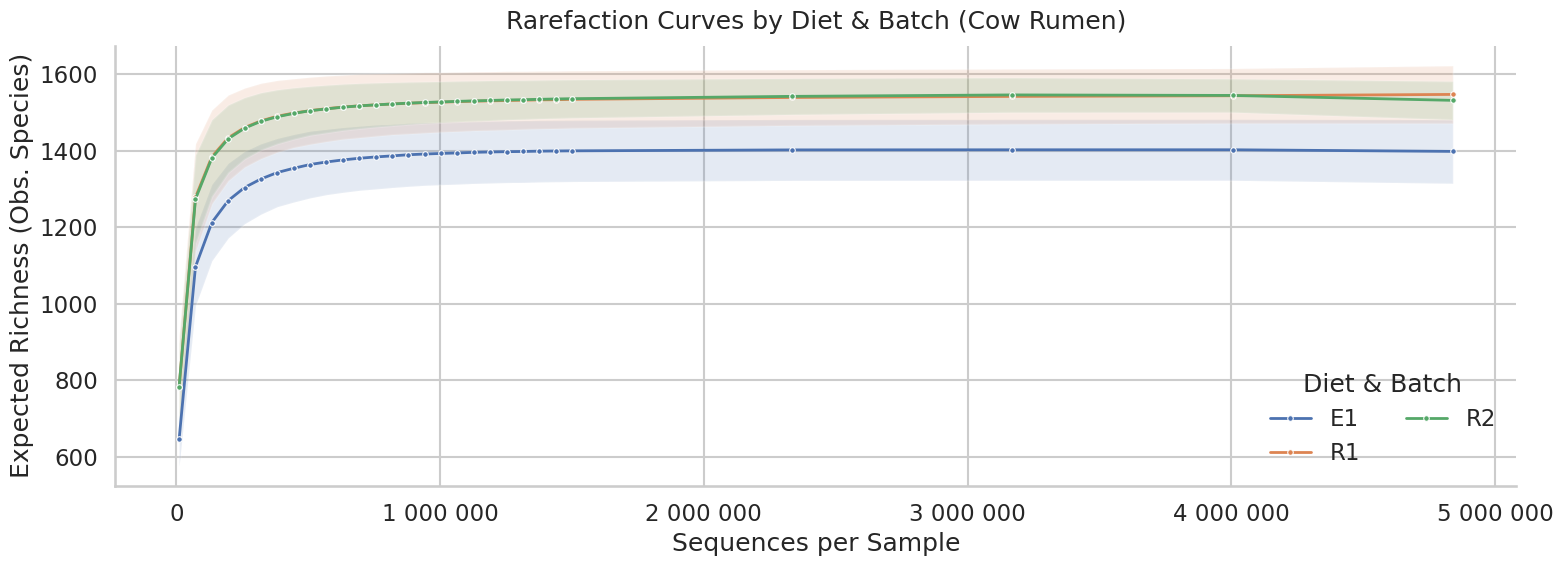

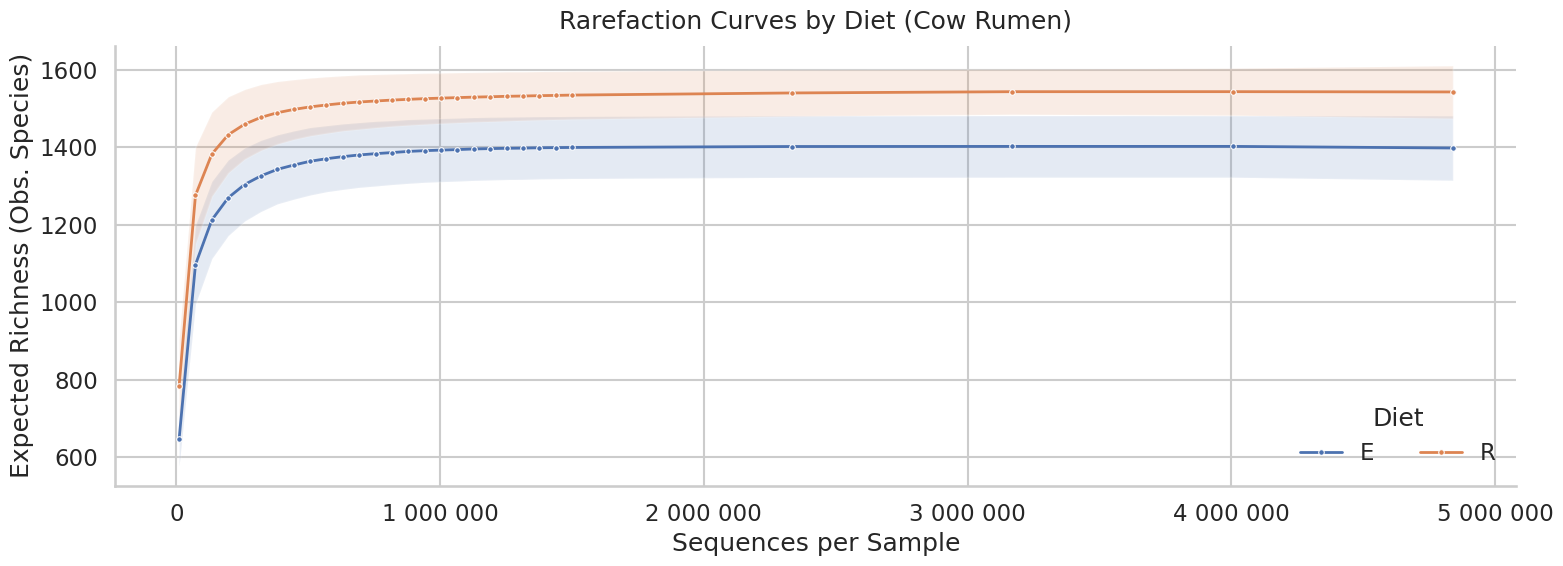

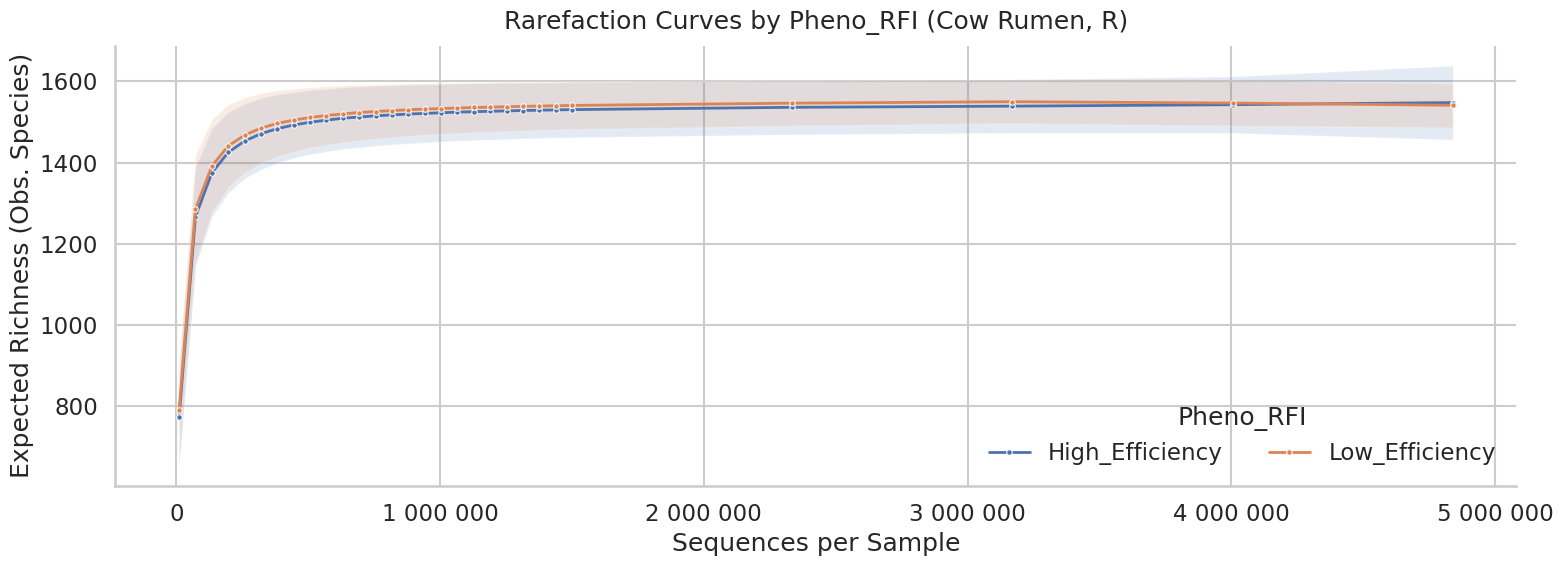

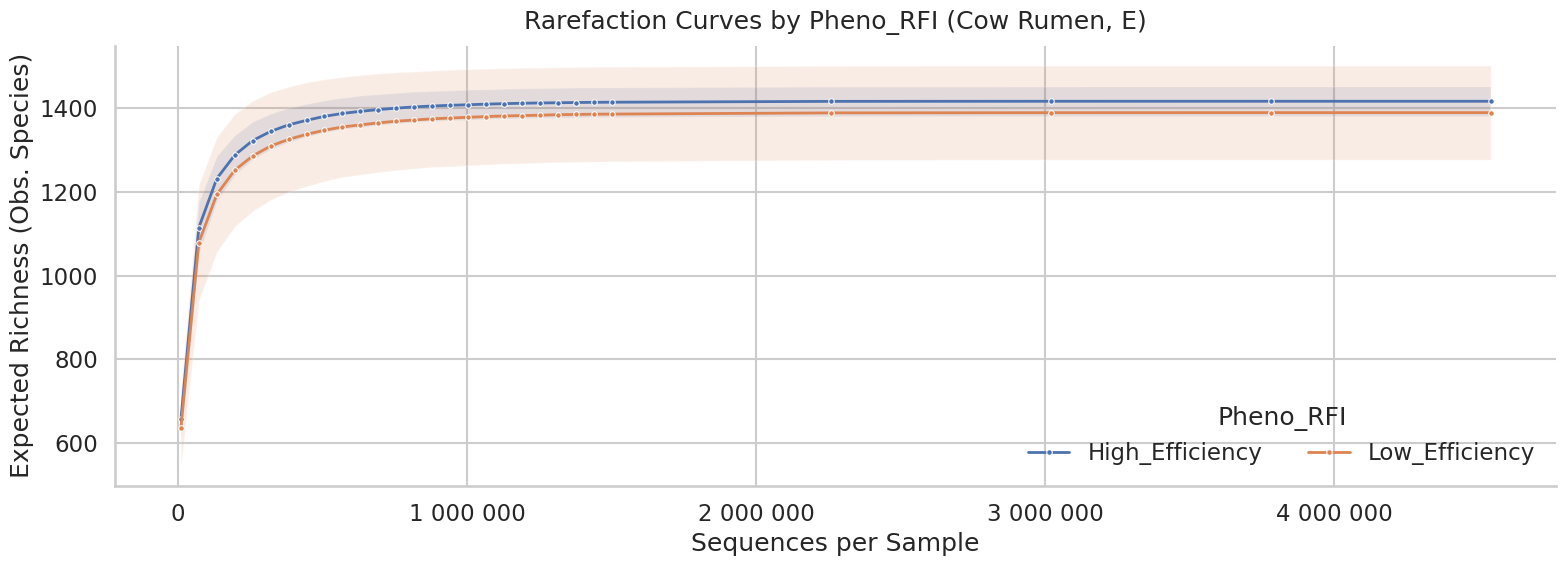

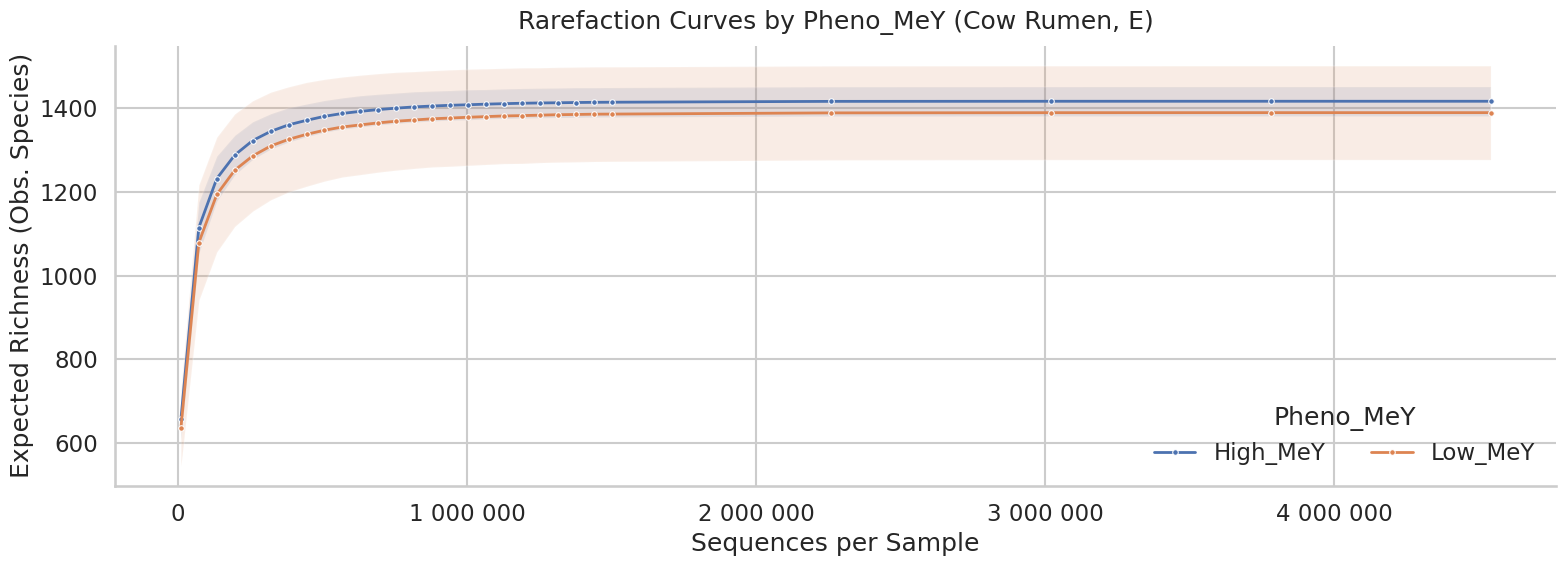

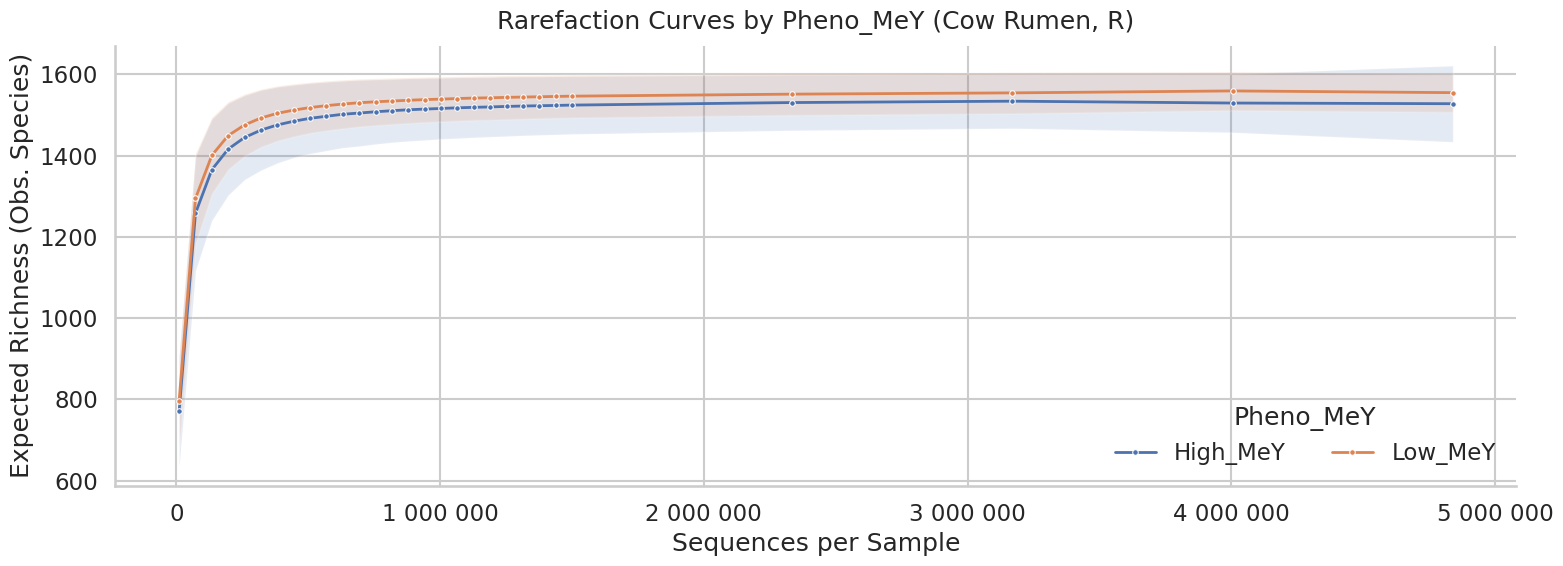

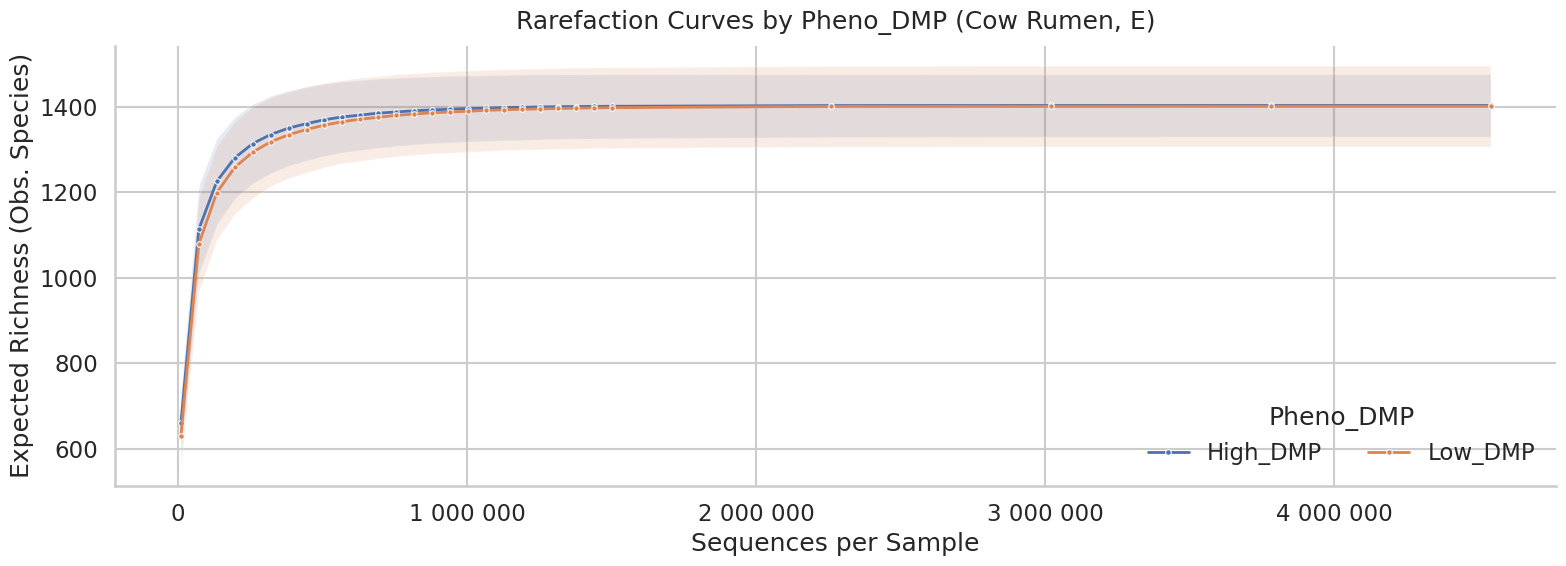

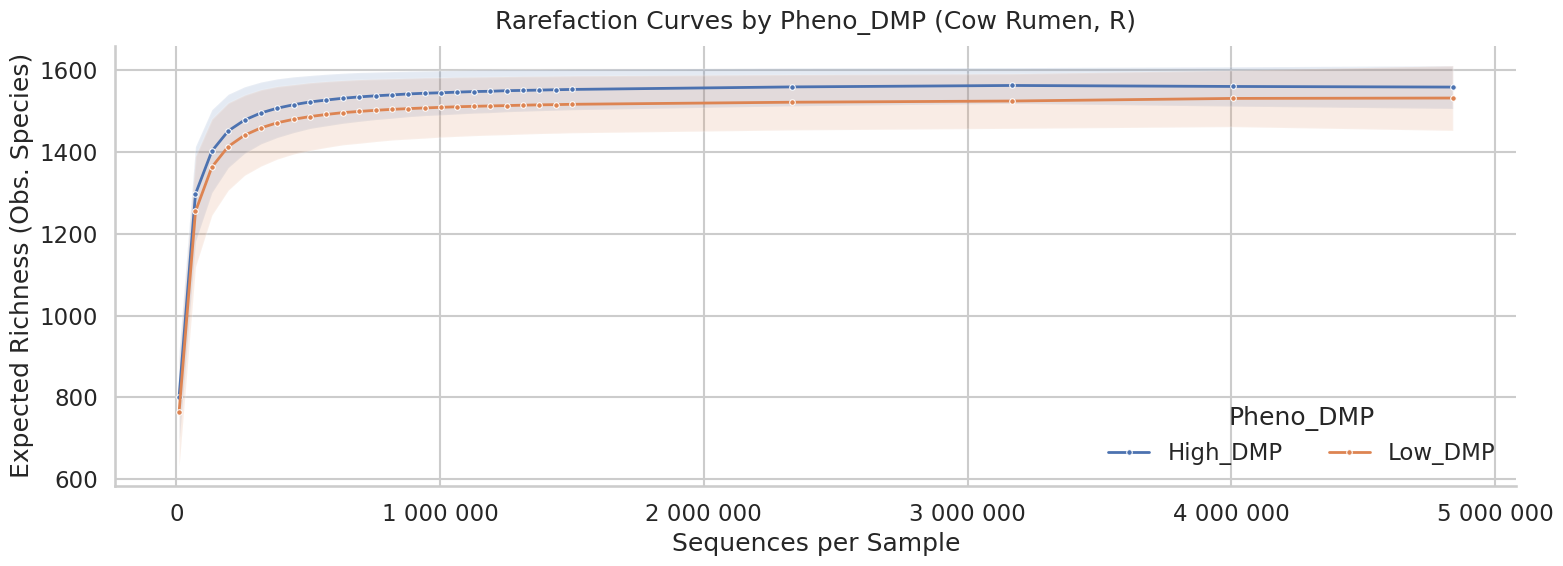

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional, Dict, List
from utils.files_utils import load_metadata, load_counts
from matplotlib.ticker import FuncFormatter

# ----------------------------- Core rarefaction -----------------------------
def rarefy_once(counts: np.ndarray, depth: int, rng: np.random.Generator) -> np.ndarray:
    """
    One rarefaction draw (without replacement) at the given depth for a single sample.
    Uses multivariate hypergeometric; counts must be non-negative integers.
    """
    total = counts.sum()
    if depth > total:
        raise ValueError(f"Depth {depth} exceeds total counts {total}.")
    if depth == 0:
        return np.zeros_like(counts)
    # True without-replacement sampling
    return rng.multivariate_hypergeometric(counts, depth)

def expected_richness(
    counts: np.ndarray,
    depths: Iterable[int],
    reps: int = 100,
    seed: Optional[int] = 0
) -> np.ndarray:
    """
    Monte-Carlo expected richness across depths for a single sample.
    Richness = number of taxa with count > 0 after rarefaction.
    """
    counts = np.asarray(counts, dtype=int)
    depths = np.asarray(list(depths), dtype=int)
    rng = np.random.default_rng(seed)
    out = np.empty(depths.size, dtype=float)

    total = counts.sum()
    depths = depths[depths <= total]   # guard against oversampling
    if depths.size == 0:
        return np.array([])

    for i, d in enumerate(depths):
        # replicate rarefaction and average richness
        rich = 0
        for _ in range(reps):
            subs = rarefy_once(counts, d, rng)
            rich += np.count_nonzero(subs)
        out[i] = rich / reps
    return out

# ----------------------------- Driver / plotting -----------------------------
def rarefaction_curves(
    df: pd.DataFrame,
    depths: Optional[Iterable[int]] = None,
    reps: int = 100,
    seed: int = 0,
) -> pd.DataFrame:
    """
    Compute expected richness for all samples in df (rows=samples, cols=taxa).
    Returns a tidy DataFrame with columns: sample, depth, richness.
    """
    if depths is None:
        max_depth = int(df.sum(axis=1).max())
        # Choose a sensible grid: denser at low depth
        step = max(1, max_depth // 50)
        depths = np.arange(step, max_depth + 1, step)

    records = []
    for sample, row in df.iterrows():
        vec = row.values.astype(int)
        # Remove negative/NaN
        vec[np.isnan(vec)] = 0
        if (vec < 0).any():
            raise ValueError(f"Negative counts found in sample '{sample}'.")
        rich = expected_richness(vec, depths, reps=reps, seed=seed)
        d_ok = np.asarray(list(depths))
        d_ok = d_ok[d_ok <= vec.sum()]
        for d, r in zip(d_ok, rich):
            records.append({"sample": sample, "depth": int(d), "richness": float(r)})
    return pd.DataFrame(records)

def plot_rarefaction(
    raref_df: pd.DataFrame,
    group_by: Optional[pd.Series] = None,
    title: str = "Rarefaction curves",
    alpha_lines: float = 0.25,
    lw_mean: float = 2.5,
    figsize=(8,6),
):
    """
    Plot per-sample curves (faint) and optional group means (bold).
    group_by: pd.Series indexed by sample name with categorical labels.
    """
    plt.figure(figsize=figsize)

    # per-sample
    for s, sdf in raref_df.groupby("sample"):
        plt.plot(sdf["depth"], sdf["richness"], alpha=alpha_lines)

    # optional group means
    if group_by is not None:
        # attach group labels
        gmap = group_by.to_dict()
        raref_df = raref_df.copy()
        raref_df["group"] = raref_df["sample"].map(gmap)
        # mean by (group, depth)
        gmean = (raref_df
                 .dropna(subset=["group"])
                 .groupby(["group", "depth"], as_index=False)["richness"]
                 .mean())
        for g, gdf in gmean.groupby("group"):
            gdf = gdf.sort_values("depth")
            plt.plot(gdf["depth"], gdf["richness"], label=f"{g} (mean)", linewidth=lw_mean)

        plt.legend(title="Groups", frameon=False)

    plt.xlabel("Sequencing depth")
    plt.ylabel("Expected richness")
    plt.title(title)
    plt.tight_layout()
    plt.show()


MG1_MG2_cow_db_S_diet_batch_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
                     Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'diet_batch',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Diet & Batch (Cow Rumen)',
    'fig_legend' : 'Diet & Batch',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_diet_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv'),
                     Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv'),
                      Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'diet_batch',
    'map_metadata_categories' : {'E1' : 'E', 'R1' : 'R', 'R2' : 'R'},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Diet (Cow Rumen)',
    'fig_legend' : 'Diet',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_pheno_RFI_R_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'Pheno_RFI',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Pheno_RFI (Cow Rumen, R)',
    'fig_legend' : 'Pheno_RFI',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_pheno_DMP_R_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'Pheno_DMP',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Pheno_DMP (Cow Rumen, R)',
    'fig_legend' : 'Pheno_DMP',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_pheno_MeY_R_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/all_R/combat_seq.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/all_R/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'Pheno_MeY',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Pheno_MeY (Cow Rumen, R)',
    'fig_legend' : 'Pheno_MeY',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_pheno_RFI_E_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'Pheno_RFI',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Pheno_RFI (Cow Rumen, E)',
    'fig_legend' : 'Pheno_RFI',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_pheno_DMP_E_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'Pheno_DMP',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Pheno_DMP (Cow Rumen, E)',
    'fig_legend' : 'Pheno_DMP',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }

MG1_MG2_cow_db_S_pheno_MeY_E_settings = {
    'counts_tsv' : [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Normalization/S/E1/counts.tsv')],
    'metadata_tsv': [Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Groups/metadata/S/E1/metadata.tsv')],
    'metadata_id_col': 'mg_work_id',
    'hue_col' : 'Pheno_MeY',
    'map_metadata_categories' : {},
    'starting_raref_depths' : (10000, 1500000, 25),
    'end_raref_depths_range' : 5,
    'raref_reps' : 50,
    'fig_title' : 'Rarefaction Curves by Pheno_MeY (Cow Rumen, E)',
    'fig_legend' : 'Pheno_MeY',
    'output_dir' : Path('/home/jpereira/Results/kraken_snake/MG1_MG2_cow_db/Diversity/Raref')
    }


load_settings = {
    'MG1_MG2_cow_db_S_diet_batch' : MG1_MG2_cow_db_S_diet_batch_settings,
    'MG1_MG2_cow_db_S_diet' : MG1_MG2_cow_db_S_diet_settings,
    'MG1_MG2_cow_db_S_pheno_RFI_R' : MG1_MG2_cow_db_S_pheno_RFI_R_settings,
    'MG1_MG2_cow_db_S_pheno_RFI_E': MG1_MG2_cow_db_S_pheno_RFI_E_settings,
    'MG1_MG2_cow_db_S_pheno_MeY_E' : MG1_MG2_cow_db_S_pheno_MeY_E_settings,
    'MG1_MG2_cow_db_S_pheno_MeY_R' : MG1_MG2_cow_db_S_pheno_MeY_R_settings,
    'MG1_MG2_cow_db_S_pheno_DMP_E' : MG1_MG2_cow_db_S_pheno_DMP_E_settings,
    'MG1_MG2_cow_db_S_pheno_DMP_R' : MG1_MG2_cow_db_S_pheno_DMP_R_settings,
    }

for key, item in load_settings.items():
    
    try:
        work_name = key
        counts_tsv = load_settings[work_name]['counts_tsv']
        metadata_tsv = load_settings[work_name]['metadata_tsv']
        metadata_id_col = load_settings[work_name]['metadata_id_col']
        hue_col = load_settings[work_name]['hue_col']
        map_metadata_categories = load_settings[work_name]['map_metadata_categories']
        starting_raref_depths = load_settings[work_name]['starting_raref_depths']
        end_raref_depths_range = load_settings[work_name]['end_raref_depths_range']
        raref_reps = load_settings[work_name]['raref_reps']
        fig_title = load_settings[work_name]['fig_title']
        fig_legend = load_settings[work_name]['fig_legend']
        output_dir = load_settings[work_name]['output_dir']

        output_dir.mkdir(exist_ok=True, parents=True)

        counts_df = load_counts(counts_tsv, sep='\t', index_col=0, transpose=False)
        metadata_df = load_metadata(metadata_tsv, sep='\t', id_col=metadata_id_col)


        # Depth grid (custom or auto)
        max_total = int(counts_df.sum(axis=1).max())
        depths = np.unique(
            np.concatenate([
                np.linspace(*starting_raref_depths, dtype=int),
                np.linspace(starting_raref_depths[1], max_total/2, end_raref_depths_range, dtype=int)
            ])
        )

        raref_df = rarefaction_curves(counts_df, depths=depths, reps=raref_reps, seed=42)

        if len(map_metadata_categories) != 0:
            metadata_df[hue_col] = metadata_df[hue_col].map(map_metadata_categories)
        group_d = metadata_df[hue_col].to_dict()

        wide_df = raref_df.pivot(index='sample', columns='depth', values='richness')
        long_df = wide_df.reset_index().melt(
            id_vars='sample', var_name='depth', value_name='richness'
        )

        # # Ensure numeric depth
        long_df['depth'] = pd.to_numeric(long_df['depth'], errors='coerce')
        # # Map groups; fill missing labels just in case
        long_df[hue_col] = long_df['sample'].map(group_d).fillna('NA')

        # (Optional) Summarize for faster plotting with explicit mean/sd
        summary = (
            long_df
            .groupby([hue_col, 'depth'], as_index=False)
            .agg(mean_richness=('richness', 'mean'),
                sd=('richness', 'std'),
                n=('richness', 'size'))
        )
        summary['se'] = summary['sd'] / np.sqrt(summary['n'])

        # --- Plot style ---
        sns.set_theme(style="whitegrid", context="talk")  # bigger fonts, clean grid

        fig, ax = plt.subplots(figsize=(16, 6))

        # Mean lines
        sns.lineplot(
            data=summary,
            x='depth', y='mean_richness',
            hue=hue_col,
            linewidth=2,
            marker="o",  # subtle markers
            markersize=4,
            ax=ax
        )

        # Error bands: mean ± SD (change to 'se' for standard error if you prefer)
        for (grp, df_g) in summary.groupby(hue_col):
            ax.fill_between(
                df_g['depth'],
                df_g['mean_richness'] - df_g['sd'],
                df_g['mean_richness'] + df_g['sd'],
                alpha=0.15
            )

        # Axes formatting
        ax.set_title(fig_title, pad=12)
        ax.set_xlabel("Sequences per Sample")
        ax.set_ylabel("Expected Richness (Obs. Species)")

        # Readable x-ticks (e.g., 10 000 instead of 10000)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " ")))

        # Legend polish
        leg = ax.legend(title=fig_legend, frameon=False, ncol=2, handlelength=1.8)

        sns.despine()
        plt.tight_layout()
        plt.savefig(output_dir / f"rarefaction.{work_name}.png")
        #plt.show()
    except Exception as e:
        print(f"[ERROR]: {e}")
        print("Failed alpha rarefaction plot")
    else:
        print(f"\n[{work_name}]:Alpha Rarefaction plot finished!\n")
        

In [ ]:
rel_abundances = abundances_df.div(abundances_df.sum(axis=1), axis=0)
rel_abundances[rel_abundances >= cfg['rel_abundance_threshold']].dropna(how='all').columns


name,Prevotella sp902799765,Prevotella sp902798285,Prevotella sp900314985,Prevotella sp902776935,Prevotella bryantii,Prevotella sp902760345,Prevotella sp900314715,Prevotella sp902782305,Prevotella sp946405145,Prevotella ruminicola,...,UBA3637 sp017960645,Enterousia sp937901165,Enterousia sp016301865,RGIG990 sp937911295,JAAYLN01 sp012521875,Limenecus sp944322545,Nanosyncoccus sp017515925,Campylobacter sp017940085,JAGOCT01 sp029553545,Methanocatella sp017553445
NS001_MG,0.066084,0.015237,0.017894,0.014934,0.007590,0.010027,0.005924,0.008715,0.008369,0.013388,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS002_MG,0.045949,0.105168,0.000052,0.000025,0.004193,0.000071,0.000072,0.000561,0.001539,0.002778,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS003_MG,0.014894,0.099845,0.009152,0.000819,0.003141,0.001931,0.000497,0.017347,0.000213,0.002688,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS004_MG,0.050763,0.061618,0.001911,0.003931,0.001248,0.004701,0.001301,0.012713,0.005871,0.002096,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS005_MG,0.306562,0.033580,0.002094,0.004976,0.000754,0.002107,0.000500,0.002188,0.001747,0.001565,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS006_MG,0.120689,0.061560,0.008352,0.002747,0.002905,0.000629,0.000181,0.000267,0.000599,0.001570,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS007_MG,0.060087,0.024086,0.004899,0.000604,0.019601,0.000162,0.000135,0.011874,0.004944,0.002381,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS008_MG,0.003656,0.055701,0.001280,0.003241,0.004972,0.024201,0.000751,0.009509,0.000631,0.003341,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS009_MG,0.016876,0.007523,0.000446,0.004245,0.000696,0.000907,0.002000,0.002412,0.000568,0.003579,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NS010_MG,0.008248,0.079057,0.000716,0.002790,0.001215,0.001023,0.009618,0.004121,0.004108,0.001076,...,0.000017,0.000006,0.000007,0.000032,0.000003,0.000029,0.000002,0.000002,0.000012,0.000003


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from typing import Iterable, Optional

# ─── Core Rarefaction Functions ───────────────────────────────────────────────
def rarefy_once(counts: np.ndarray, depth: int, rng: np.random.Generator) -> np.ndarray:
    """One rarefaction draw (without replacement) for a single sample."""
    total = counts.sum()
    if depth > total:
        raise ValueError(f"Depth {depth} exceeds total counts {total}.")
    if depth == 0:
        return np.zeros_like(counts)
    return rng.multivariate_hypergeometric(counts, depth)


def expected_richness(counts: np.ndarray,
                      depths: Iterable[int],
                      reps: int = 100,
                      seed: Optional[int] = 0) -> np.ndarray:
    """Monte Carlo expected richness across depths for one sample."""
    counts = np.asarray(counts, dtype=int)
    depths = np.asarray(list(depths), dtype=int)
    rng = np.random.default_rng(seed)

    total = counts.sum()
    depths = depths[depths <= total]
    if depths.size == 0:
        return np.array([])

    out = np.empty(depths.size, dtype=float)
    for i, d in enumerate(depths):
        richness_values = []
        for _ in range(reps):
            subs = rarefy_once(counts, d, rng)
            richness_values.append(np.count_nonzero(subs))
        out[i] = np.mean(richness_values)
    return out


def rarefaction_curves(df: pd.DataFrame,
                       depths: Optional[Iterable[int]] = None,
                       reps: int = 100,
                       seed: int = 0) -> pd.DataFrame:
    """Compute expected richness for all samples in df (rows=samples, cols=taxa)."""
    if depths is None:
        max_depth = int(df.sum(axis=1).max())
        step = max(1, max_depth // 50)
        depths = np.arange(step, max_depth + 1, step)

    records = []
    for sample, row in df.iterrows():
        vec = row.fillna(0).values.astype(int)
        if (vec < 0).any():
            raise ValueError(f"Negative counts found in sample '{sample}'.")
        rich = expected_richness(vec, depths, reps=reps, seed=seed)
        valid_depths = np.asarray(list(depths))
        valid_depths = valid_depths[valid_depths <= vec.sum()]
        for d, r in zip(valid_depths, rich):
            records.append({"sample": sample, "depth": int(d), "richness": float(r)})
    return pd.DataFrame(records)


# ─── Settings Dictionaries ────────────────────────────────────────────────────
MG2_GTDB_S_settings = {
    'raw_counts_tsv': Path("/home/jpereira/Results/kraken_snake/MG2_20M/Data/merge_bracken/S/bracken_merged_S_new_est_reads.csv"),
    'metadata_tsv': Path("/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/S/metadata/metadata.NS_R.tsv"),
    'output_dir': Path("/home/jpereira/Results/kraken_snake/MG1_20M/Visuals/div_metrics/"),
    'title': "Rarefaction Curves by Diet & Batch (Cow Rumen)",
    'hue_col': 'Efficiency',
    'id_col': 'LABID',
    'apply_rel_abundance_filter': True,
    'rel_abundance_threshold': 0.00000,  # 0.01%
    'reps': 50,
    'seed': 42,
}

load_settings = {'MG2_GTDB_S': MG2_GTDB_S_settings}
work_name = 'MG2_GTDB_S'
cfg = load_settings[work_name]

# ─── Output Directory ─────────────────────────────────────────────────────────
output_dir = cfg['output_dir']
output_dir.mkdir(parents=True, exist_ok=True)

# ─── Load Data ────────────────────────────────────────────────────────────────
abundances_df = pd.read_csv(cfg['raw_counts_tsv'], sep=',', index_col=0).T
metadata_df = pd.read_csv(cfg['metadata_tsv'], sep='\t')

# ─── Apply Relative Abundance Filter (Optional) ───────────────────────────────
if cfg['apply_rel_abundance_filter']:
    thr = cfg['rel_abundance_threshold']
    print(f"Applying relative abundance filter by MEAN across samples: taxa < {thr*100:.4f}% discarded")

    # Per-sample relative abundance; avoid divide-by-zero
    sample_sums = abundances_df.sum(axis=1).replace(0, np.nan)
    rel_abundances = abundances_df.div(sample_sums, axis=0)

    # Mean across samples for each taxon (skip NaNs from zero-sum samples)
    mean_rel = rel_abundances.mean(axis=0, skipna=True)

    # Keep taxa whose mean relative abundance >= threshold
    taxa_to_keep = mean_rel[mean_rel >= thr].index

    before = abundances_df.shape[1]
    abundances_df = abundances_df.loc[:, taxa_to_keep]
    after = abundances_df.shape[1]

    print(f"Kept {after}/{before} taxa ({after/before*100:.2f}%)")

# ─── Depth Grid ───────────────────────────────────────────────────────────────
max_total = int(abundances_df.sum(axis=1).max())
depths = np.unique(
    np.concatenate([
        np.linspace(10_000, 1_500_000, 25, dtype=int),
        np.linspace(1_500_000, max_total / 2, 4, dtype=int)
    ])
)

# ─── Compute Rarefaction Curves ───────────────────────────────────────────────
print(f"Running rarefaction: {cfg['reps']} replicates × {len(depths)} depths …")
raref_df = rarefaction_curves(abundances_df, depths=depths, reps=cfg['reps'], seed=cfg['seed'])

# ─── Map Metadata Groups ──────────────────────────────────────────────────────
hue_col = cfg['hue_col']
id_col = cfg['id_col']

if id_col not in metadata_df.columns:
    raise ValueError(f"'{id_col}' not found in metadata columns: {list(metadata_df.columns)}")
if hue_col not in metadata_df.columns:
    raise ValueError(f"'{hue_col}' not found in metadata columns: {list(metadata_df.columns)}")

metadata_df[id_col] = metadata_df[id_col].astype(str)
group_dict = metadata_df.set_index(id_col)[hue_col].to_dict()
raref_df[hue_col] = raref_df['sample'].map(group_dict).fillna('Unassigned')

# ─── Summarize for Mean ± SD ─────────────────────────────────────────────────
summary = (
    raref_df
    .groupby([hue_col, 'depth'], as_index=False)
    .agg(mean_richness=('richness', 'mean'),
         sd=('richness', 'std'),
         n=('richness', 'size'))
)
summary['se'] = summary['sd'] / np.sqrt(summary['n'])

# ─── Plot Rarefaction Curves ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(16, 6))

sns.lineplot(
    data=summary,
    x='depth',
    y='mean_richness',
    hue=hue_col,
    linewidth=2,
    marker="o",
    markersize=4,
    ax=ax
)

for grp, df_g in summary.groupby(hue_col):
    ax.fill_between(
        df_g['depth'],
        df_g['mean_richness'] - df_g['sd'],
        df_g['mean_richness'] + df_g['sd'],
        alpha=0.15
    )

ax.set_title(cfg['title'], pad=12)
ax.set_xlabel("Sequencing Depth")
ax.set_ylabel("Expected Richness (Observed Species)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " ")))
ax.legend(title=hue_col, frameon=False, ncol=2, handlelength=1.8)
sns.despine()
plt.tight_layout()

# ─── Save Figure ──────────────────────────────────────────────────────────────
suffix = "_filtered" if cfg['apply_rel_abundance_filter'] else ""
output_path = output_dir / f"rarefaction_curves{suffix}.png"
plt.savefig(output_path, dpi=300)
plt.show()
print(f"[OK] Saved: {output_path}")


FileNotFoundError: [Errno 2] No such file or directory: '/home/jpereira/Results/kraken_snake/MG1_MG2_GTDB/Groups/S/metadata/metadata.NS_R.tsv'

## Barplots Abundance

,Efficiency,depth,mean_richness,sd,n,se
0,E,0,0.0,0.0,6225,0.0


In [ ]:
combat_counts_g_tsv = "/home/jpereira/Results/kraken_snake/MG1_MG2/Normalization/Genera/Efficiency.cov/all_R/combat_seq.all_R.tsv"
combat_counts_g_df = pd.read_csv(combat_counts_g_tsv, sep = '\t', index_col=0).T

display(metadata_df.head())

display(combat_counts_g_df.head())

,LABID,Dieta,DMI,ADG,BW,mBW,BFAT,RFI,Pheno_RFI,DMP,Vis,Days,MeI_BW,MeI_ADG,MeY_DMI,Pheno_MeY,Pheno_DMP,batch,diet_batch
work_id,,,,,,,,,,,,,,,,,,,
NS001_MG,PR26NR008,R,7.32,1.37,365.0,75.3,5.0,-2.772,High_Efficiency,181.77,107,41,0.50,104.83,19.12,Low_MeY,Low_DMP,B,R2
PR26NR067MG,PR26NR067,R,8.35,1.48,355.5,82.2,4.6,-2.400,High_Efficiency,190.38,175,59,0.54,129.05,22.80,High_MeY,Low_DMP,A,R1
PR26NR063MG,PR26NR063,R,8.84,1.43,333.5,78.0,4.7,-1.534,High_Efficiency,197.56,166,63,0.59,113.94,20.78,High_MeY,High_DMP,A,R1
PR26NR042MG,PR26NR042,R,8.22,1.16,321.5,76.1,2.7,-1.493,High_Efficiency,179.22,75,23,0.56,154.36,21.80,High_MeY,Low_DMP,A,R1
NS002_MG,PR26NR046,R,10.00,1.31,398.5,89.1,4.5,-0.988,High_Efficiency,200.65,106,59,0.50,153.28,20.07,High_MeY,High_DMP,B,R2


,Prevotella,UBA4293,UBA4372,UBA2918,UBA4334,UBA1179,UBA1786,UBA3839,Ga6A1,UBA6382,...,Campylobacter,Methanobrevibacter_A,Methanobrevibacter,Methanobrevibacter_B,Methanosphaera,CADBMS01,Methanomethylophilus,ISO4-G1,UBA7597,UMGS1490
PR26NR067MG,5586894.0,69391.0,294377.0,53647.0,75005.0,15073.0,8655.0,8238.0,15349.0,45849.0,...,0.0,77651.0,26666.0,911.0,865.0,327.0,715.0,410.0,0.0,0.0
PR26NR063MG,5136726.0,331164.0,461763.0,25092.0,53316.0,99128.0,20971.0,15359.0,12329.0,12926.0,...,99.0,69797.0,20215.0,3502.0,1321.0,756.0,1706.0,1603.0,64.0,115.0
PR26NR042MG,4105352.0,112218.0,383333.0,25037.0,92511.0,31051.0,11701.0,21671.0,16012.0,24729.0,...,144.0,112063.0,29101.0,4327.0,1856.0,897.0,4228.0,2144.0,99.0,130.0
PR26NR026MG,6381181.0,229343.0,451279.0,126693.0,78520.0,44807.0,20601.0,15055.0,8241.0,50028.0,...,113.0,99554.0,26031.0,3850.0,1582.0,797.0,5447.0,2160.0,85.0,0.0
PR26NR007MG,3844169.0,116949.0,591566.0,100680.0,47162.0,15146.0,6414.0,7651.0,5764.0,26529.0,...,153.0,114647.0,41083.0,5610.0,2704.0,1290.0,1279.0,835.0,107.0,157.0


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_taxon_boxplot(
    counts_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    taxon: str,
    group_col: str,
    metadata_index: str = "work_id",
    normalize: str | None = None,  # None | "relative" | "cpm"
    log_scale: bool = False,
    pseudocount: float = 1.0,
    order: list | None = None,
    show_points: bool = True,
    figsize=(9, 6),
    title: str | None = None,
    palette: str | list | None = "Set2"
):
    """
    Make a boxplot of a given taxon’s abundance grouped by a categorical column.

    Parameters
    ----------
    counts_df : DataFrame
        Rows = samples (index), columns = taxa; values are counts or normalized counts.
    metadata_df : DataFrame
        Must contain sample identifiers (as index or in `metadata_index`) and a categorical `group_col`.
    taxon : str
        Column name in `counts_df` to plot.
    group_col : str
        Categorical column in `metadata_df` used to group samples on the x-axis.
    metadata_index : str
        Column in `metadata_df` that holds sample IDs if not already the index (default: "work_id").
    normalize : {"relative", "cpm", None}
        - None: use values as-is
        - "relative": divide each sample by its total (fraction)
        - "cpm": counts per million (relative * 1e6)
    log_scale : bool
        If True, plot log10(abundance + pseudocount).
    pseudocount : float
        Value added before log transform to avoid log(0).
    order : list[str] | None
        Explicit order for category levels; if None, order by median abundance (descending).
    show_points : bool
        Overlay individual sample points (stripplot) on top of boxes.
    figsize : tuple
        Figure size.
    title : str | None
        Custom title; default uses taxon and group_col.
    palette : seaborn palette name or list
        Color palette.

    Returns
    -------
    matplotlib.axes.Axes
    """
    # Ensure metadata is indexed by sample IDs
    md = metadata_df.copy()
    if md.index.name != metadata_index and metadata_index in md.columns:
        md = md.set_index(metadata_index)

    # Basic checks
    if taxon not in counts_df.columns:
        # helpful suggestion if close match exists
        similar = sorted(
            [c for c in counts_df.columns if taxon.lower() in str(c).lower()],
            key=len
        )[:5]
        suggestion = f" Did you mean one of: {similar}?" if similar else ""
        raise ValueError(f"Taxon '{taxon}' not found in counts_df columns.{suggestion}")

    if group_col not in md.columns:
        raise ValueError(f"Column '{group_col}' not found in metadata_df.")

    # Align samples present in both tables
    common = counts_df.index.intersection(md.index)
    if common.empty:
        raise ValueError("No overlapping samples between counts_df and metadata_df.")
    cdf = counts_df.loc[common]
    md = md.loc[common]

    # Compute abundance vector for the selected taxon
    y = cdf[taxon].astype(float)

    # Optional normalization
    if normalize is not None:
        totals = cdf.sum(axis=1).replace(0, np.nan)
        rel = y / totals
        if normalize == "relative":
            y = rel
        elif normalize == "cpm":
            y = rel * 1e6
        else:
            raise ValueError("normalize must be one of: None, 'relative', 'cpm'")

    # Build tidy dataframe
    df = pd.DataFrame({
        "sample": common,
        "abundance": y.values,
        group_col: md[group_col].astype("category")
    }).dropna(subset=["abundance"])

    # Optional log transform
    if log_scale:
        df["abundance_plot"] = np.log10(df["abundance"] + float(pseudocount))
        ylab = f"log10({('relative ' if normalize=='relative' else 'CPM ' if normalize=='cpm' else '')}abundance + {pseudocount})"
    else:
        df["abundance_plot"] = df["abundance"]
        if normalize == "relative":
            ylab = "Relative abundance"
        elif normalize == "cpm":
            ylab = "Abundance (CPM)"
        else:
            ylab = "Abundance"

    # Order categories by median abundance if not provided
    if order is None:
        order = (
            df.groupby(group_col)["abundance_plot"]
              .median()
              .sort_values(ascending=False)
              .index.tolist()
        )

    # Count samples per group for x-tick labels
    counts = df[group_col].value_counts()
    xtick_labels = {lvl: f"{lvl} (n={counts.get(lvl, 0)})" for lvl in order}

    # ---- Plot ----
    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df, x=group_col, y="abundance_plot",
        order=order, ax=ax, showfliers=False, width=0.6, palette=palette
    )

    if show_points:
        sns.stripplot(
            data=df, x=group_col, y="abundance_plot",
            order=order, ax=ax, dodge=False, alpha=0.6, jitter=0.2
        )

    # Labels & formatting
    ax.set_xlabel(group_col)
    ax.set_ylabel(ylab)
    ax.set_title(title or f"{taxon} abundance by {group_col}", pad=12)

    # Pretty y-axis (commas) when not log and not relative
    if not log_scale and normalize not in ("relative",):
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " ")))

    # Replace x-tick labels with n per group
    ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)
    ax.set_ylim(bottom=0)

    sns.despine()
    plt.tight_layout()
    return ax



In [ ]:
metadata_df.head(2)

,LABID,Dieta,DMI,ADG,BW,mBW,BFAT,RFI,Pheno_RFI,DMP,Vis,Days,MeI_BW,MeI_ADG,MeY_DMI,Pheno_MeY,Pheno_DMP,batch,diet_batch
work_id,,,,,,,,,,,,,,,,,,,
NS001_MG,PR26NR008,R,7.32,1.37,365.0,75.3,5.0,-2.772,High_Efficiency,181.77,107,41,0.50,104.83,19.12,Low_MeY,Low_DMP,B,R2
PR26NR067MG,PR26NR067,R,8.35,1.48,355.5,82.2,4.6,-2.400,High_Efficiency,190.38,175,59,0.54,129.05,22.80,High_MeY,Low_DMP,A,R1


/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


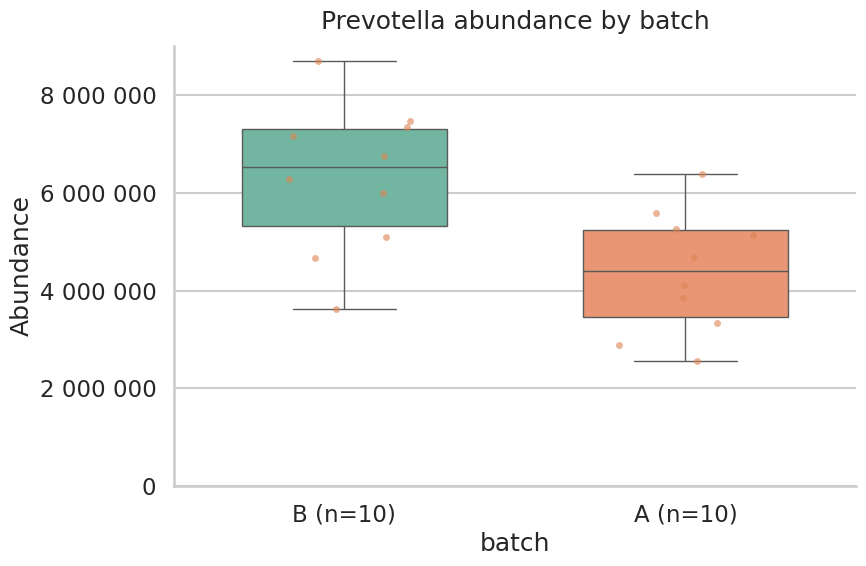

In [ ]:
# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Prevotella",      # or any genus present as a column
    group_col="batch",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()


/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


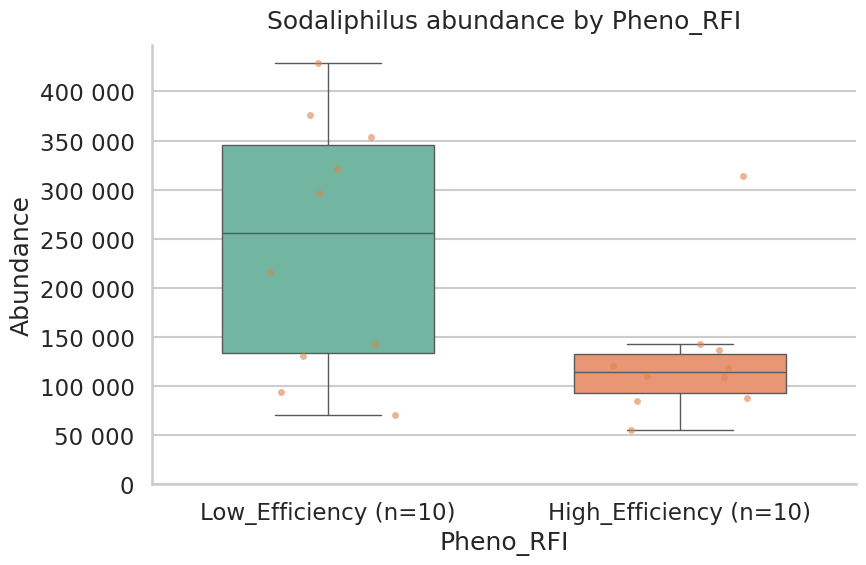

In [ ]:
# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Sodaliphilus",      # or any genus present as a column
    group_col="Pheno_RFI",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()




/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


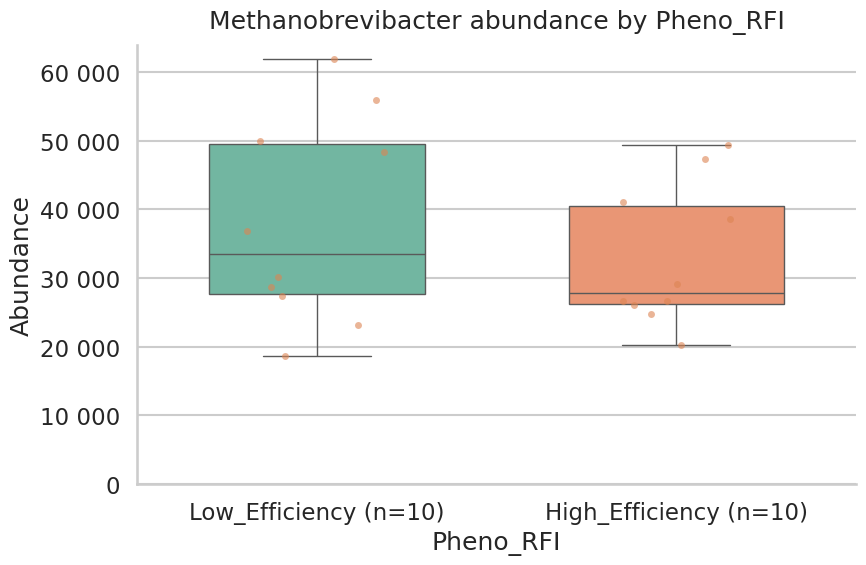

/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


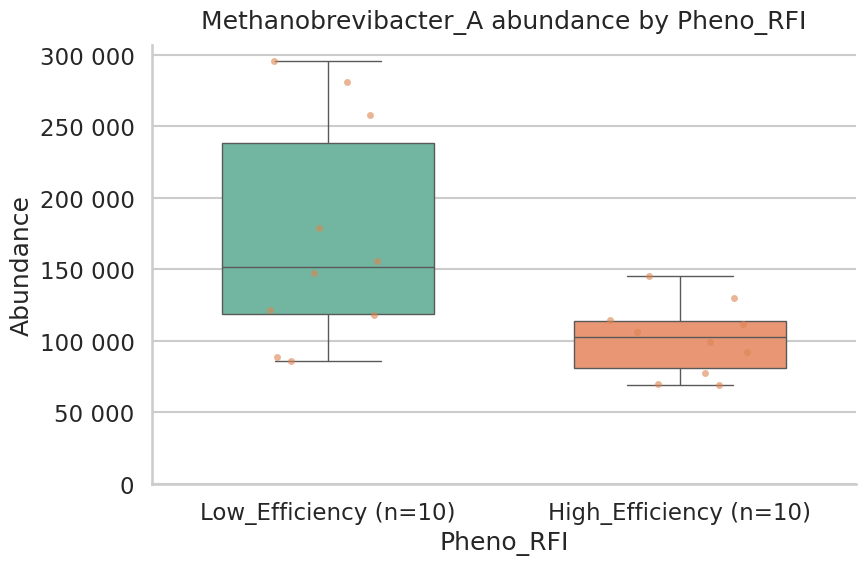

/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


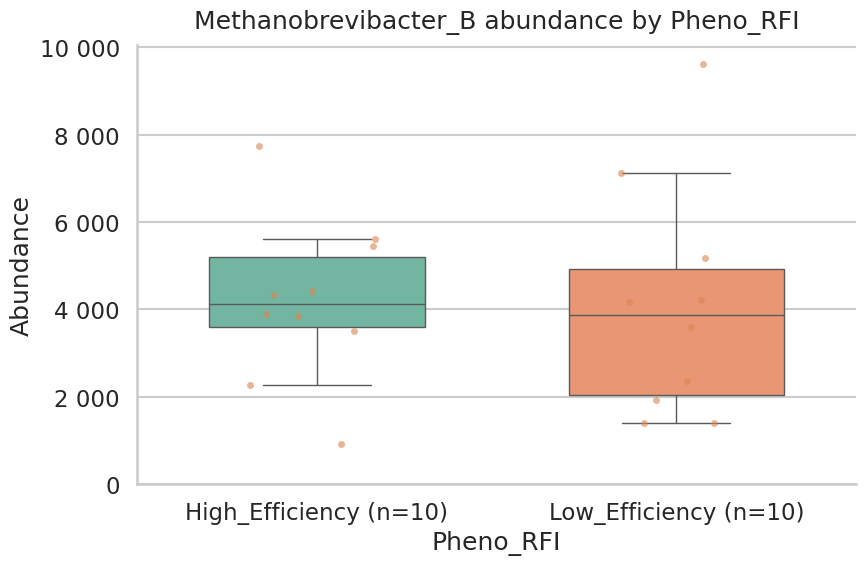

In [ ]:
# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Methanobrevibacter",      # or any genus present as a column
    group_col="Pheno_RFI",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()

# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Methanobrevibacter_A",      # or any genus present as a column
    group_col="Pheno_RFI",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()

# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Methanobrevibacter_B",      # or any genus present as a column
    group_col="Pheno_RFI",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()

In [ ]:
metadata_df

,LABID,Dieta,DMI,ADG,BW,mBW,BFAT,RFI,Pheno_RFI,DMP,Vis,Days,MeI_BW,MeI_ADG,MeY_DMI,Pheno_MeY,Pheno_DMP,batch,diet_batch
work_id,,,,,,,,,,,,,,,,,,,
NS001_MG,PR26NR008,R,7.32,1.37,365.0,75.3,5.0,-2.772,High_Efficiency,181.77,107,41,0.50,104.83,19.12,Low_MeY,Low_DMP,B,R2
PR26NR067MG,PR26NR067,R,8.35,1.48,355.5,82.2,4.6,-2.400,High_Efficiency,190.38,175,59,0.54,129.05,22.80,High_MeY,Low_DMP,A,R1
PR26NR063MG,PR26NR063,R,8.84,1.43,333.5,78.0,4.7,-1.534,High_Efficiency,197.56,166,63,0.59,113.94,20.78,High_MeY,High_DMP,A,R1
PR26NR042MG,PR26NR042,R,8.22,1.16,321.5,76.1,2.7,-1.493,High_Efficiency,179.22,75,23,0.56,154.36,21.80,High_MeY,Low_DMP,A,R1
NS002_MG,PR26NR046,R,10.00,1.31,398.5,89.1,4.5,-0.988,High_Efficiency,200.65,106,59,0.50,153.28,20.07,High_MeY,High_DMP,B,R2
PR26NR026MG,PR26NR026,R,9.69,1.19,388.0,87.3,3.6,-0.925,High_Efficiency,234.25,47,19,0.60,197.26,24.17,High_MeY,High_DMP,A,R1
NS003_MG,PR26NR025,R,9.71,1.38,344.5,79.9,5.9,-0.787,High_Efficiency,192.10,109,57,0.56,138.78,19.79,High_MeY,Low_DMP,B,R2
NS004_MG,PR26NR051,R,10.23,1.39,372.0,85.0,6.5,-0.668,High_Efficiency,217.43,81,43,0.58,156.96,21.26,High_MeY,High_DMP,B,R2
PR26NR007MG,PR26NR007,R,8.77,0.73,352.5,81.3,2.7,-0.631,High_Efficiency,196.27,83,40,0.56,269.21,22.38,High_MeY,Low_DMP,A,R1


/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


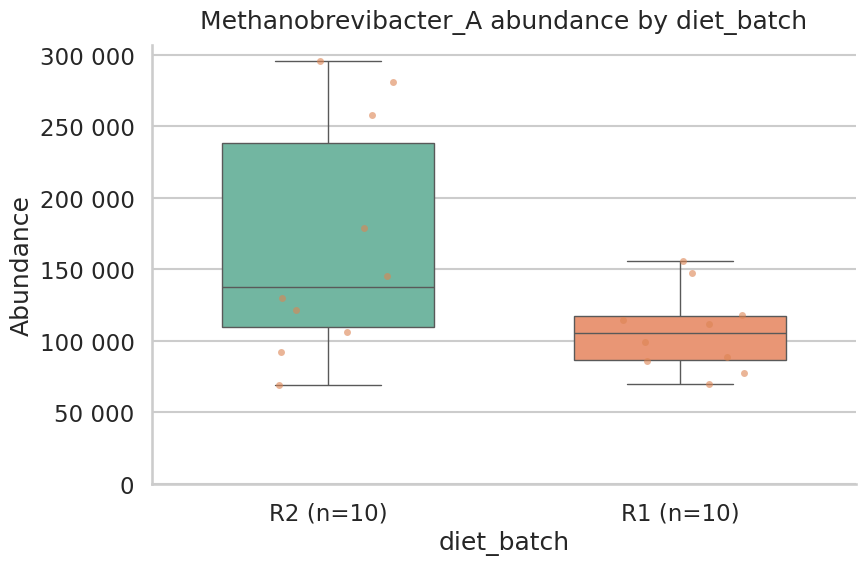

/tmp/ipykernel_3007001/3005526906.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col)["abundance_plot"]
/tmp/ipykernel_3007001/3005526906.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3007001/3005526906.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_labels[l] for l in order], rotation=0)


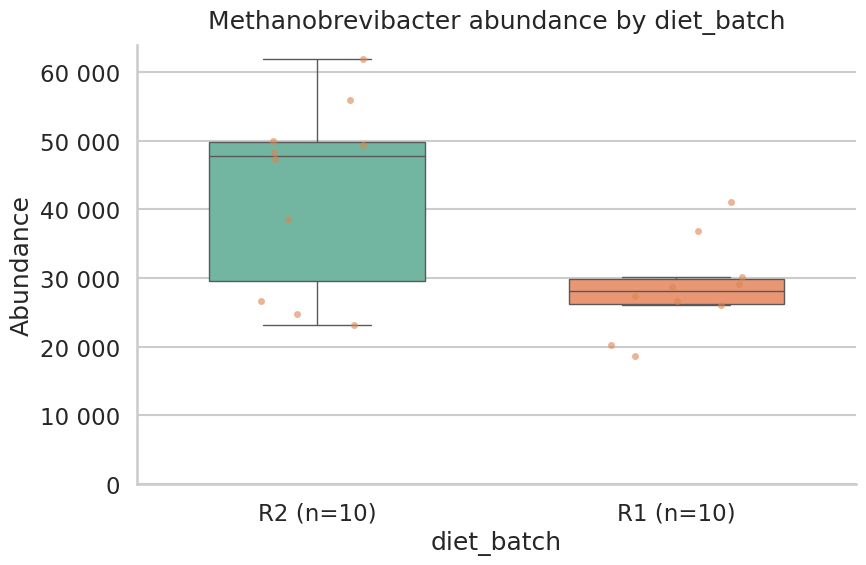

In [ ]:
# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Methanobrevibacter_A",      # or any genus present as a column
    group_col="diet_batch",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()

# counts: samples x genera (columns), metadata indexed by 'work_id'
ax = plot_taxon_boxplot(
    counts_df=combat_counts_g_df,
    metadata_df=metadata_df,
    taxon="Methanobrevibacter",      # or any genus present as a column
    group_col="diet_batch",       # e.g., "batch", "Pheno_RFI", etc.
    metadata_index="work_id",
    normalize=None,          # or "relative", "cpm"
    log_scale=False,          # often helpful for overdispersed counts
    pseudocount=1.0
)
plt.show()

# Old Code 

In [ ]:
def make_pcoa(
    abundance_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    hue_col: str,
    fig_path: str,
    metric: str = "euclidean",
    intersect_dfs: bool = False,
    show_plot: bool = False,
    title = ''
):
    # 1. (Optional) sync up samples
    if intersect_dfs:
        shared = abundance_df.index.intersection(metadata_df.index)
        abundance_df = abundance_df.loc[shared]
        metadata_df  = metadata_df.loc[shared]

    # 2. compute distance matrix
    #    for CLR data: metric="euclidean"; for raw counts: "braycurtis"
    dm = beta_diversity(metric, abundance_df.values, ids=abundance_df.index.astype(str))

    # 3. run PCoA
    pcoa_res = pcoa(DistanceMatrix(dm, ids=abundance_df.index.astype(str)))

    # 4. save coordinates
    coords = pcoa_res.samples
    coords.to_csv("pcoa_coordinates.tsv", sep="\t", header=True)

    # 5. merge with metadata
    coords_meta = coords.join(metadata_df)

    # 6. optional plotting
    if show_plot:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=coords_meta,
            x="PC1", y="PC2",
            hue=hue_col,
            palette="Set2",
            s=100, edgecolor="black"
        )
        var1 = pcoa_res.proportion_explained[0]*100
        var2 = pcoa_res.proportion_explained[1]*100
        plt.xlabel(f"PC1 ({var1:.1f}%)")
        plt.ylabel(f"PC2 ({var2:.1f}%)")
        if title:
            plt.title(title)
        else:
            plt.title(f"PCoA ({metric}) colored by {hue_col}")
        plt.grid(True)
        plt.legend(title=hue_col)
        plt.tight_layout()
        plt.savefig(fig_path)
        plt.show()

    #return pcoa_res.samples["PC1"], pcoa_res.samples["PC2"] 
    return pcoa_res

import matplotlib.pyplot as plt

def plot_pcoa_variance(pcoa_res, fig_path="pcoa_variance.png", show_plot=True):
    # Extract relative variance
    var_exp = pcoa_res.proportion_explained * 100  # convert to percentage

    # Barplot
    plt.figure(figsize=(8, 5))
    var_exp.plot(kind="bar", color="skyblue", edgecolor="black")

    plt.ylabel("Variance Explained (%)")
    plt.xlabel("Principal Coordinate")
    plt.title("PCoA Variance Explained")
    plt.xticks(rotation=45, ha="right")

    for i, v in enumerate(var_exp):
        plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")

    plt.ylim((0,100))
    plt.tight_layout()
    plt.savefig(fig_path)
    if show_plot:
        plt.show()
    plt.close()


def plot_pcoa_variance_topn(pcoa_res,
                             n: int = 5,
                             fig_path: str = "pcoa_variance_topn.png",
                             show_plot: bool = True,
                             title: str | None = None):
    """
    Barplot of the PCoA variance explained: first n PCs individually,
    remaining PCs grouped into a single bar.
    """
    # proportions as percentages
    var_exp = np.asarray(pcoa_res.proportion_explained) * 100.0

    # guardrails
    if n < 1:
        n = 1
    n = min(n, len(var_exp))

    # split top-n and remainder
    top = var_exp[:n]
    rest = var_exp[n:]
    labels = [f"PC{i+1}" for i in range(n)]
    values = list(top)
    if rest.size > 0:
        labels.append(f"PC{n+1}+")
        values.append(rest.sum())

    # barplot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, edgecolor="black")
    plt.ylabel("Variance Explained (%)")
    plt.xlabel("Principal Coordinate")
    if title:
        plt.title(title)
    else:
        plt.title(f"PCoA variance explained (first {n} PCs + remainder)")

    # add data labels
    for rect, v in zip(bars, values):
        plt.text(rect.get_x() + rect.get_width()/2.0, v + 0.6, f"{v:.1f}%",
                 ha="center", va="bottom")

    plt.tight_layout()
    plt.ylim((0,100))
    plt.savefig(fig_path, dpi=300)
    if show_plot:
        plt.show()
    plt.close()

    # return a tidy table of what was plotted (useful in reports)
    out = pd.DataFrame({"component": labels, "variance_pct": values})
    return out
